# TER Picopatt - Prediction

In [2]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import requests
#from dotenv import load_dotenv

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

import functions as fc
from functions import load_all


In [3]:
OUT = Path("outputs")
fc.create_folder(OUT)

FIG = Path(OUT, "figures/tmrt_pred")
fc.create_folder(FIG)

MFDATA = Path(OUT / "meteofrance_data")
fc.create_folder(MFDATA)

FIG_MODELS = FIG / "models"
FIG_ERRORS = FIG / "errors"
FIG_DATA   = FIG / "data_quality"

fc.create_folder(FIG_MODELS)
fc.create_folder(FIG_ERRORS)
fc.create_folder(FIG_DATA)

print("OUT:", OUT)
print("FIG:", FIG)
print("MFDATA:", MFDATA)

OUT: outputs
FIG: outputs\figures\tmrt_pred
MFDATA: outputs\meteofrance_data


In [4]:
DATA_NOZERO = Path("outputs/clean_nozeros")
bd = load_all(DATA_NOZERO, False)

required_geo = ["lon_ontrack", "lat_ontrack"]
missing_geo = [c for c in required_geo if c not in bd.columns]
if missing_geo:
    raise ValueError("Colonnes GNSS ontrack manquantes: " + ", ".join(missing_geo))

bd = bd.copy()
bd["lon_std"] = pd.to_numeric(bd["lon_ontrack"], errors="coerce")
bd["lat_std"] = pd.to_numeric(bd["lat_ontrack"], errors="coerce")

bd = bd.dropna(subset=["lon_std", "lat_std"])
bd = bd[(bd["lon_std"].between(-180, 180)) & (bd["lat_std"].between(-90, 90))]

bd = bd.reset_index(drop=True)
bd["uid"] = bd.index.astype(int)

print("bd ready:", bd.shape)
print(bd[["uid","lon_std","lat_std"]].head())


bd ready: (341281, 42)
   uid   lon_std    lat_std
0    0  3.886345  43.608305
1    1  3.886353  43.608305
2    2  3.886361  43.608304
3    3  3.886369  43.608304
4    4  3.886377  43.608303


In [5]:
AE = Path("outputs/alphaearth_data")

# Fichiers exports AlphaEarth
raw_path  = AE / "alphaearth_A00_A63_points.csv"
pca10_path = AE / "alphaearth_pca10_points.csv"
pca15_path = AE / "alphaearth_pca15_points.csv"
pca32_path = AE / "alphaearth_pca32_points.csv"

for p in [raw_path, pca10_path, pca15_path, pca32_path]:
    if not p.exists():
        raise FileNotFoundError(f"Fichier manquant: {p}")

aef_raw  = pd.read_csv(raw_path)
aef_pca10 = pd.read_csv(pca10_path)
aef_pca15 = pd.read_csv(pca15_path)
aef_pca32 = pd.read_csv(pca32_path)

# Noms des colonnes
BANDS = [f"A{i:02d}" for i in range(64)]
PCA10_COLS = [c for c in aef_pca10.columns if c.startswith("aef_pca10_")]
PCA15_COLS = [c for c in aef_pca15.columns if c.startswith("aef_pca15_")]
PCA32_COLS = [c for c in aef_pca32.columns if c.startswith("aef_pca32_")]

# Merge dans bd
df = bd.merge(aef_raw[["uid"] + BANDS], on="uid", how="left")
df = df.merge(aef_pca10[["uid"] + PCA10_COLS], on="uid", how="left")
df = df.merge(aef_pca15[["uid"] + PCA15_COLS], on="uid", how="left")
df = df.merge(aef_pca32[["uid"] + PCA32_COLS], on="uid", how="left")

print("df merged shape:", df.shape)
print("NaN embeddings raw A00:", int(df["A00"].isna().sum()))
print("NaN PCA10:", int(df[PCA10_COLS].isna().any(axis=1).sum()))

df merged shape: (341281, 163)
NaN embeddings raw A00: 0
NaN PCA10: 0


In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp", "tmrt"]).copy()

start = df["timestamp"].min()
end   = df["timestamp"].max()
print("PICOPATT range:", start, "->", end)

PICOPATT range: 2024-10-29 08:36:30 -> 2025-01-16 19:26:41


Doit créer un compte sur https://public-api.meteofrance.fr/ puis mettre le token dans .env

In [7]:
load_dotenv()
TOKEN = os.getenv("MFTOKEN","").strip()
print("Token length:", len(TOKEN))
if len(TOKEN) <= 1400:
    raise ValueError("MFTOKEN trop court. Vérifie .env (et pas tronqué).")

BASE = "https://public-api.meteofrance.fr/public/DPClim/v1"
headers = {"apikey": TOKEN}

params_cmd = {
    "id-station": "34154001",  # MONTPELLIER-AEROPORT
    "date-deb-periode": "2024-10-29T00:00:00Z",
    "date-fin-periode": "2025-01-16T23:59:59Z"
}

r = requests.get(f"{BASE}/commande-station/horaire", headers=headers, params=params_cmd, timeout=120)
print("commande status:", r.status_code, r.text[:200])
r.raise_for_status()

cmd = r.json()
num_cmde = cmd["elaboreProduitAvecDemandeResponse"]["return"]
print("num_cmde:", num_cmde)


NameError: name 'load_dotenv' is not defined

In [8]:
def download_cmd_csv(num_cmde: str, out_path: Path, max_wait_s: int = 900, sleep_s: int = 5):
    t0 = time.time()
    out_path = Path(out_path)

    while True:
        rf = requests.get(
            f"{BASE}/commande/fichier",
            headers=headers,
            params={"id-cmde": num_cmde},
            timeout=120
        )

        if rf.status_code == 201 and len(rf.content) > 0:
            out_path.write_bytes(rf.content)
            return out_path

        if rf.status_code == 204:
            pass
        elif rf.status_code == 410:
            raise RuntimeError("410: production déjà livrée. Relance une commande pour un nouveau fichier.")
        elif rf.status_code == 404:
            raise RuntimeError("404: commande inconnue. Vérifie num_cmde.")
        elif rf.status_code == 507:
            raise RuntimeError("507: production trop volumineuse. Réduis la période.")
        elif rf.status_code >= 400:
            raise RuntimeError(f"Erreur {rf.status_code}: {rf.text[:300]}")

        if time.time() - t0 > max_wait_s:
            raise TimeoutError(f"Fichier non prêt après {max_wait_s}s. Dernier status={rf.status_code}")

        time.sleep(sleep_s)

mf_csv = MFDATA / f"mf_montpellier_{num_cmde}.csv"
mf_csv = download_cmd_csv(num_cmde, mf_csv)
print("CSV météo écrit:", mf_csv)

NameError: name 'num_cmde' is not defined

In [9]:
wx = pd.read_csv(MFDATA / "mf_montpellier_2026004655806.csv", sep=";", dtype=str)

wx["DATE"] = pd.to_datetime(wx["DATE"], format="%Y%m%d%H", utc=True)

num_cols = [c for c in wx.columns if c not in ["POSTE", "DATE"]]
for c in num_cols:
    wx[c] = wx[c].str.replace(",", ".", regex=False).replace({"": None})
    wx[c] = pd.to_numeric(wx[c], errors="coerce")

wx = wx.sort_values("DATE").reset_index(drop=True)

print("wx shape:", wx.shape)
print("wx cols:", len(wx.columns))
display(wx.head(3))

wx shape: (1920, 196)
wx cols: 196


,POSTE,DATE,RR1,QRR1,DRR1,QDRR1,HNEIGEF,QHNEIGEF,NEIGETOT,QNEIGETOT,...,UV2,QUV2,INS2,QINS2,INFRAR2,QINFRAR2,DIR2,QDIR2,DIF2,QDIF2
0,34154001,2024-10-29 00:00:00+00:00,0.0,1,0.0,9.0,NaN,NaN,0,9,...,NaN,NaN,0,9,NaN,NaN,NaN,NaN,NaN,NaN
1,34154001,2024-10-29 01:00:00+00:00,0.0,1,0.0,9.0,NaN,NaN,0,9,...,NaN,NaN,0,9,NaN,NaN,NaN,NaN,NaN,NaN
2,34154001,2024-10-29 02:00:00+00:00,0.0,1,0.0,9.0,NaN,NaN,0,9,...,NaN,NaN,0,9,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df2 = df.copy()
df2["timestamp"] = pd.to_datetime(df2["timestamp"], errors="coerce")

# Hypothèse (à garder explicite): timestamp PICOPATT en Europe/Paris si naïf
if df2["timestamp"].dt.tz is None:
    df2["timestamp"] = df2["timestamp"].dt.tz_localize("Europe/Paris")

df2["timestamp_utc"] = df2["timestamp"].dt.tz_convert("UTC")

df2 = df2.sort_values("timestamp_utc")
wx2 = wx.sort_values("DATE")

dfm = pd.merge_asof(
    df2,
    wx2,
    left_on="timestamp_utc",
    right_on="DATE",
    direction="nearest",
    tolerance=pd.Timedelta("30min")
)

print("dfm shape:", dfm.shape)
print("missing MF join:", float(dfm["DATE"].isna().mean()))


dfm shape: (341281, 360)
missing MF join: 0.0


In [11]:
# Variables MF utilisées
mf_base = [
    "T",      # température
    "U",      # humidité relative
    "PSTAT",  # pression station
    "FF", "DD", "FXI",  # vent + rafales
    "RR1",    # pluie (mm/1h)
    "N",      # nébulosité totale
    "INS",    # durée d’ensoleillement
    "GLO", "DIR", "DIF",  # rayonnement global/direct/diffus 
    "WW",     # temps présent (code)
    "VV"      # visibilité
]

mf_base = [c for c in mf_base if c in dfm.columns]

# Qualité: colonnes Qxxx associées si présentes
mf_q = [f"Q{c}" for c in mf_base if f"Q{c}" in dfm.columns]

# Option robuste: indicateurs de "manquant"
mf_missing_flags = []
for c in mf_base:
    flag = f"{c}_missing"
    dfm[flag] = dfm[c].isna().astype(int)
    mf_missing_flags.append(flag)

mf_features = mf_base + mf_q + mf_missing_flags

print("MF base:", mf_base)
print("MF quality cols:", mf_q[:10], "… total", len(mf_q))
print("MF features total:", len(mf_features))

MF base: ['T', 'U', 'PSTAT', 'FF', 'DD', 'FXI', 'RR1', 'N', 'INS', 'GLO', 'DIR', 'DIF', 'WW', 'VV']
MF quality cols: ['QT', 'QU', 'QPSTAT', 'QFF', 'QDD', 'QFXI', 'QRR1', 'QN', 'QINS', 'QGLO'] … total 14
MF features total: 42


In [12]:
def drop_all_nan_cols(df_, cols):
    cols = [c for c in cols if c in df_.columns]
    keep = [c for c in cols if df_[c].notna().any()]
    dropped = sorted(set(cols) - set(keep))
    return keep, dropped

TARGET = "tmrt"

ae_pca10 = [c for c in dfm.columns if c.startswith("aef_pca10_")]
ae_raw   = [f"A{i:02d}" for i in range(64) if f"A{i:02d}" in dfm.columns]

train = dfm.dropna(subset=[TARGET, "DATE"]).copy()
train["day_utc"] = train["timestamp_utc"].dt.floor("D")

mf_features, dropped_mf = drop_all_nan_cols(train, mf_features)
ae_pca10, dropped_p10 = drop_all_nan_cols(train, ae_pca10)
ae_raw, dropped_raw = drop_all_nan_cols(train, ae_raw)

print("train:", train.shape)
print("Dropped MF all-NaN:", dropped_mf)
print("Dropped AE PCA10 all-NaN:", dropped_p10)
print("Dropped AE raw all-NaN:", dropped_raw)

train: (341281, 375)
Dropped MF all-NaN: ['DIF', 'DIR', 'QDIF', 'QDIR']
Dropped AE PCA10 all-NaN: []
Dropped AE raw all-NaN: []


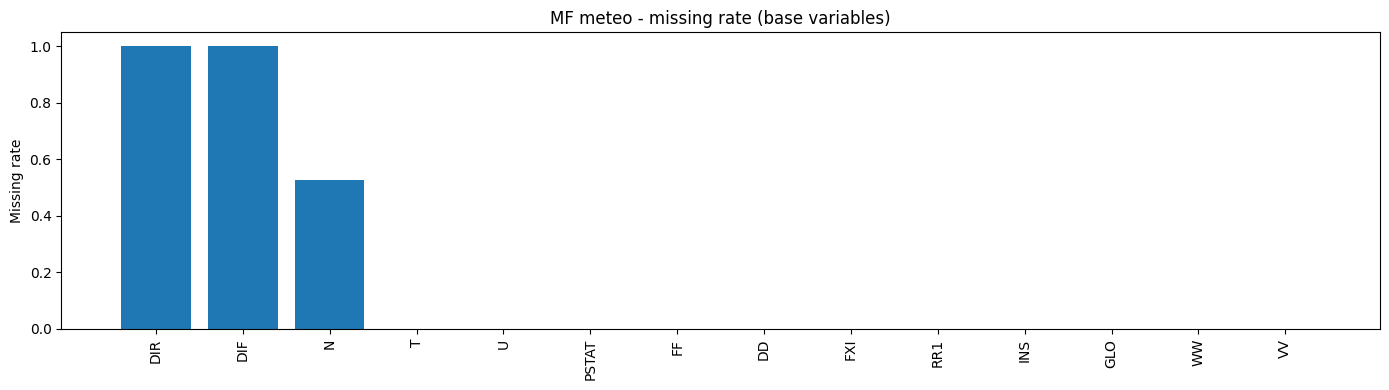

Figure enregistrée: outputs\figures\tmrt_pred\data_quality\mf_missing_rate.png


In [13]:
miss = train[mf_base].isna().mean().sort_values(ascending=False)

plt.figure(figsize=(14,4))
plt.bar(miss.index, miss.values)
plt.xticks(rotation=90)
plt.ylabel("Missing rate")
plt.title("MF meteo - missing rate (base variables)")
plt.tight_layout()

out_fig = FIG_DATA / "mf_missing_rate.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)


In [14]:
from sklearn.model_selection import GroupShuffleSplit

train["day_utc"] = train["timestamp_utc"].dt.floor("D")
groups = train["day_utc"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

def make_split(X, y):
    tr, te = next(gss.split(X, y, groups=groups))
    return tr, te


In [15]:
groups = train["day_utc"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

def make_split(X, y):
    tr, te = next(gss.split(X, y, groups=groups))
    return tr, te

In [17]:
def eval_set(name, feat_cols):
    X = train[feat_cols]
    y = train[TARGET].astype(float)

    tr, te = make_split(X, y)

    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("reg", HistGradientBoostingRegressor(random_state=42))
    ])

    model.fit(X.iloc[tr], y.iloc[tr])
    pred = model.predict(X.iloc[te])

    return {
        "set": name,
        "rmse": mean_squared_error(y.iloc[te], pred) ** 0.5,
        "mae": mean_absolute_error(y.iloc[te], pred),
        "r2": r2_score(y.iloc[te], pred),
        "n_test": len(te)
    }, (tr, te)

results = []
splits = {}

res, sp = eval_set("MF_only", mf_features)
results.append(res); splits["MF_only"] = sp

if len(ae_pca10) > 0:
    res, sp = eval_set("MF_plus_AE_PCA10", mf_features + ae_pca10)
    results.append(res); splits["MF_plus_AE_PCA10"] = sp

if len(ae_raw) > 0:
    res, sp = eval_set("MF_plus_AE_raw64", mf_features + ae_raw)
    results.append(res); splits["MF_plus_AE_raw64"] = sp

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
display(results_df)

out_csv = MFDATA / "tmrt_pred_global_results.csv"
results_df.to_csv(out_csv, index=False)
print("Résultats exportés:", out_csv)

,set,rmse,mae,r2,n_test
0,MF_plus_AE_raw64,6.290248,4.042767,0.601370,67070
1,MF_plus_AE_PCA10,6.527573,4.019945,0.570722,67070
2,MF_only,8.069766,5.202445,0.343920,67070


Résultats exportés: outputs\meteofrance_data\tmrt_pred_global_results.csv


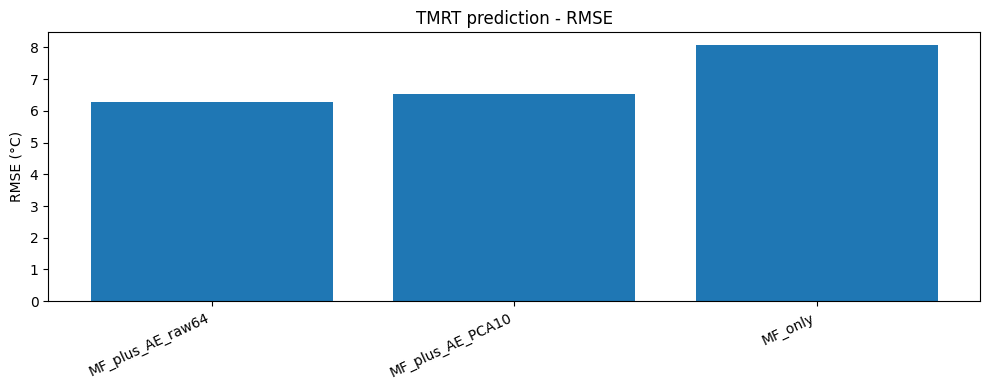

Figure enregistrée: outputs\figures\tmrt_pred\models\rmse_by_set.png


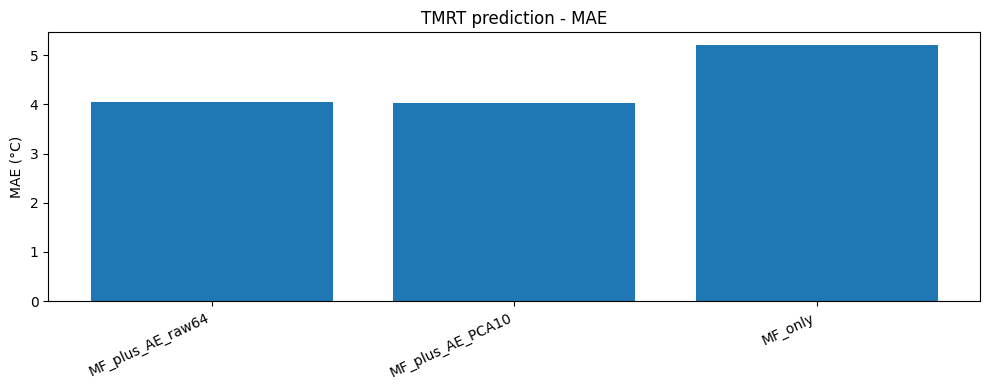

Figure enregistrée: outputs\figures\tmrt_pred\models\mae_by_set.png


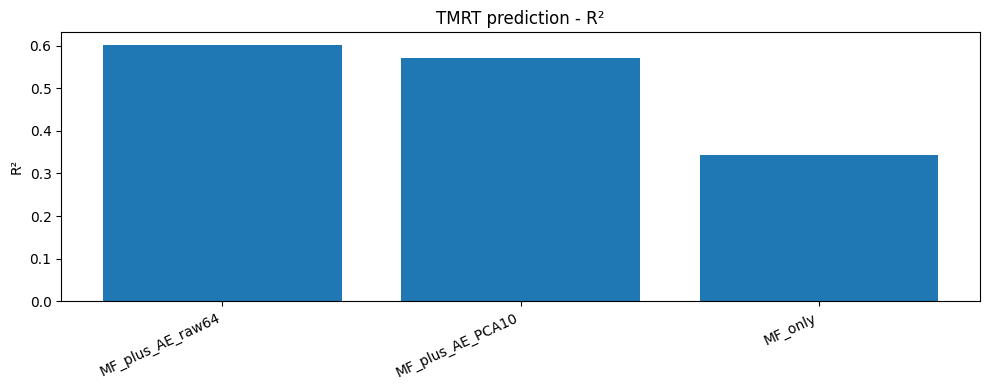

Figure enregistrée: outputs\figures\tmrt_pred\models\r2_by_set.png


In [18]:
plt.figure(figsize=(10,4))
plt.bar(results_df["set"], results_df["rmse"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("RMSE (°C)")
plt.title("TMRT prediction - RMSE")
plt.tight_layout()
out_fig = FIG_MODELS / "rmse_by_set.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)

plt.figure(figsize=(10,4))
plt.bar(results_df["set"], results_df["mae"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("MAE (°C)")
plt.title("TMRT prediction - MAE")
plt.tight_layout()
out_fig = FIG_MODELS / "mae_by_set.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)

plt.figure(figsize=(10,4))
plt.bar(results_df["set"], results_df["r2"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("R²")
plt.title("TMRT prediction - R²")
plt.tight_layout()
out_fig = FIG_MODELS / "r2_by_set.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)


In [19]:
best_set = results_df.iloc[0]["set"]
print("Best set:", best_set)

if best_set == "MF_only":
    feat_cols = mf_features
elif best_set == "MF_plus_AE_PCA10":
    feat_cols = mf_features + ae_pca10
else:
    feat_cols = mf_features + ae_raw

X = train[feat_cols]
y = train[TARGET].astype(float)
tr, te = splits[best_set]

model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("reg", HistGradientBoostingRegressor(random_state=42))
])
model.fit(X.iloc[tr], y.iloc[tr])
pred = model.predict(X.iloc[te])

test_rows = train.iloc[te].copy()
test_rows["tmrt_pred"] = pred
test_rows["err"] = test_rows["tmrt_pred"] - test_rows["tmrt"]

print("Test rows:", test_rows.shape)

Best set: MF_plus_AE_raw64
Test rows: (67070, 377)


In [20]:
pred_csv = MFDATA / f"tmrt_pred_testrows_{best_set}.csv"
test_rows[["uid","timestamp","timestamp_utc","tmrt","tmrt_pred","err","track_id","M_slot","section_id","lon_ontrack","lat_ontrack"]\
         if all(c in test_rows.columns for c in ["uid","track_id","M_slot","section_id","lon_ontrack","lat_ontrack"]) \
         else ["timestamp","timestamp_utc","tmrt","tmrt_pred","err"]].to_csv(pred_csv, index=False)

print("Export test_rows:", pred_csv)

Export test_rows: outputs\meteofrance_data\tmrt_pred_testrows_MF_plus_AE_raw64.csv


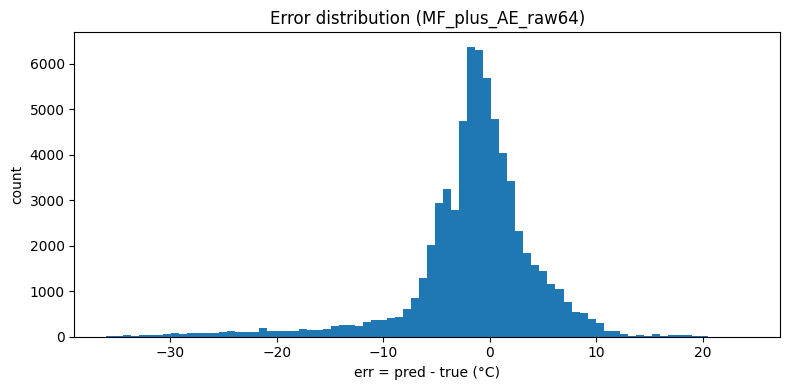

Figure enregistrée: outputs\figures\tmrt_pred\errors\error_hist.png


In [21]:
plt.figure(figsize=(8,4))
plt.hist(test_rows["err"].dropna(), bins=80)
plt.xlabel("err = pred - true (°C)")
plt.ylabel("count")
plt.title(f"Error distribution ({best_set})")
plt.tight_layout()
out_fig = FIG_ERRORS / "error_hist.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)


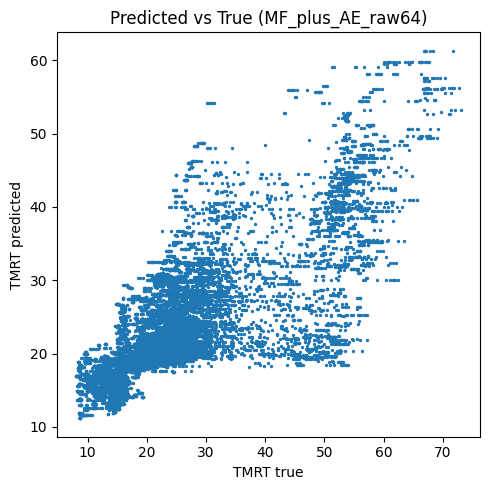

Figure enregistrée: outputs\figures\tmrt_pred\errors\pred_vs_true.png


In [22]:
sample = test_rows.sample(n=min(30000, len(test_rows)), random_state=42)

plt.figure(figsize=(5,5))
plt.scatter(sample["tmrt"], sample["tmrt_pred"], s=2)
plt.xlabel("TMRT true")
plt.ylabel("TMRT predicted")
plt.title(f"Predicted vs True ({best_set})")
plt.tight_layout()
out_fig = FIG_ERRORS / "pred_vs_true.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)


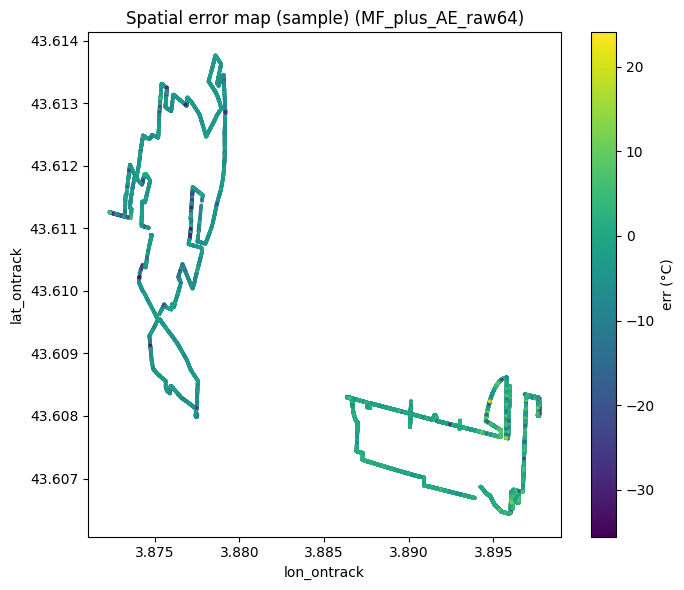

Figure enregistrée: outputs\figures\tmrt_pred\errors\spatial_error_map.png


In [23]:
if {"lon_ontrack","lat_ontrack"}.issubset(test_rows.columns):
    plot_df = test_rows.sample(n=min(20000, len(test_rows)), random_state=42)
    plt.figure(figsize=(7,6))
    plt.scatter(plot_df["lon_ontrack"], plot_df["lat_ontrack"], c=plot_df["err"], s=3)
    plt.colorbar(label="err (°C)")
    plt.xlabel("lon_ontrack")
    plt.ylabel("lat_ontrack")
    plt.title(f"Spatial error map (sample) ({best_set})")
    plt.tight_layout()
    out_fig = FIG_ERRORS / "spatial_error_map.png"
    plt.savefig(out_fig, dpi=150)
    plt.show()
    print("Figure enregistrée:", out_fig)
else:
    print("lon_ontrack/lat_ontrack absents")


In [24]:
err = test_rows["err"].to_numpy()

summary = {
    "set": best_set,
    "n": int(np.sum(~np.isnan(err))),
    "mean_err": float(np.nanmean(err)),
    "median_err": float(np.nanmedian(err)),
    "mae": float(np.nanmean(np.abs(err))),
    "rmse": float(np.sqrt(np.nanmean(err**2))),
    "p05_abs_err": float(np.nanpercentile(np.abs(err), 5)),
    "p50_abs_err": float(np.nanpercentile(np.abs(err), 50)),
    "p95_abs_err": float(np.nanpercentile(np.abs(err), 95)),
}

summary_df = pd.DataFrame([summary])
display(summary_df)

out_csv = MFDATA / "tmrt_pred_error_summary.csv"
summary_df.to_csv(out_csv, index=False)
print("Résumé exporté:", out_csv)


,set,n,mean_err,median_err,mae,rmse,p05_abs_err,p50_abs_err,p95_abs_err
0,MF_plus_AE_raw64,67070,-1.485732,-0.985496,4.042767,6.290248,0.22183,2.472979,13.491963


Résumé exporté: outputs\meteofrance_data\tmrt_pred_error_summary.csv


group_cols: ['track_id', 'M_slot', 'section_id']


,track_id,M_slot,section_id,n,mae,rmse,bias,p95_abs
318,ecusson,M2,62,25.0,29.583196,29.600141,-29.583196,30.431791
322,ecusson,M2,66,50.0,25.471376,25.603151,-25.471376,28.395851
300,ecusson,M2,44,91.0,24.685622,25.516982,-24.685622,30.449644
357,ecusson,M3,33,51.0,25.107246,25.245628,-25.107246,26.737550
258,ecusson,M1,75,107.0,22.793687,23.804400,-22.476955,32.023824
366,ecusson,M3,43,68.0,20.262698,23.054625,-20.262698,33.529256
344,ecusson,M3,16,30.0,21.383274,22.526176,-21.383274,30.496913
333,ecusson,M3,2,45.0,21.382205,21.864988,-21.382205,29.442211
320,ecusson,M2,64,36.0,18.132917,21.063427,-18.132917,34.534923
352,ecusson,M3,27,40.0,18.750792,20.873446,-18.750792,31.120134


Export err_by: outputs\meteofrance_data\tmrt_pred_error_by_groups.csv


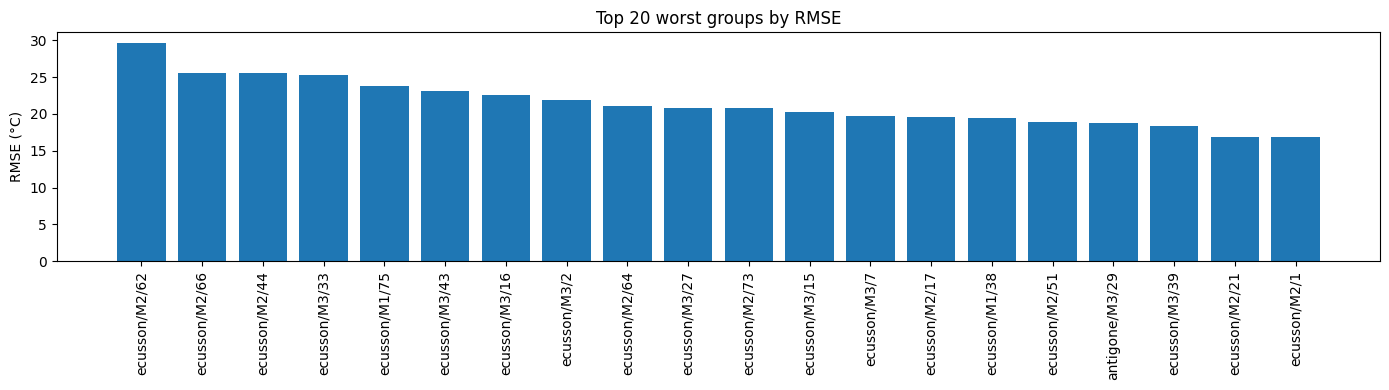

Figure enregistrée: outputs\figures\tmrt_pred\errors\top20_groups_rmse.png


In [25]:
group_cols = [c for c in ["track_id", "M_slot", "section_id"] if c in test_rows.columns]
print("group_cols:", group_cols)

def agg_err(g):
    e = g["err"].to_numpy()
    return pd.Series({
        "n": len(e),
        "mae": np.mean(np.abs(e)),
        "rmse": np.sqrt(np.mean(e**2)),
        "bias": np.mean(e),
        "p95_abs": np.percentile(np.abs(e), 95)
    })

if group_cols:
    err_by = (test_rows.groupby(group_cols)
              .apply(agg_err)
              .reset_index()
              .sort_values("rmse", ascending=False))

    display(err_by.head(25))

    out_csv = MFDATA / "tmrt_pred_error_by_groups.csv"
    err_by.to_csv(out_csv, index=False)
    print("Export err_by:", out_csv)

    top = err_by.head(20).copy()
    labels = ["/".join(map(str, row)) for row in top[group_cols].values]

    plt.figure(figsize=(14,4))
    plt.bar(range(len(top)), top["rmse"])
    plt.xticks(range(len(top)), labels, rotation=90)
    plt.ylabel("RMSE (°C)")
    plt.title("Top 20 worst groups by RMSE")
    plt.tight_layout()
    out_fig = FIG_ERRORS / "top20_groups_rmse.png"
    plt.savefig(out_fig, dpi=150)
    plt.show()
    print("Figure enregistrée:", out_fig)

else:
    print("Pas de colonnes track_id / M_slot / section_id")


C:\Users\Youssef El Alaoui\AppData\Local\Temp\ipykernel_5956\775345874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")


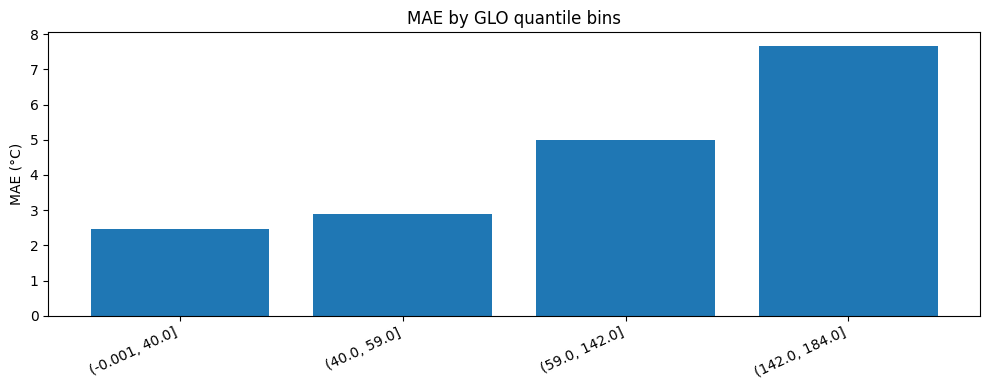

Figure enregistrée: outputs\figures\tmrt_pred\errors\mae_by_GLO_bins.png


C:\Users\Youssef El Alaoui\AppData\Local\Temp\ipykernel_5956\775345874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")


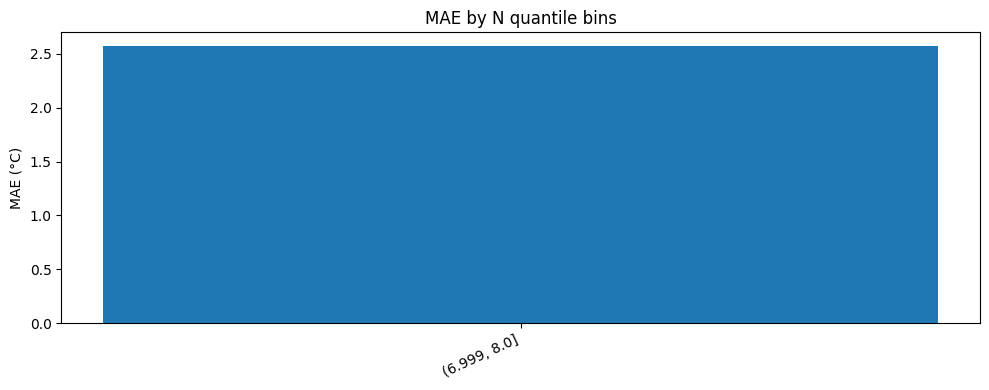

Figure enregistrée: outputs\figures\tmrt_pred\errors\mae_by_N_bins.png


C:\Users\Youssef El Alaoui\AppData\Local\Temp\ipykernel_5956\775345874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")


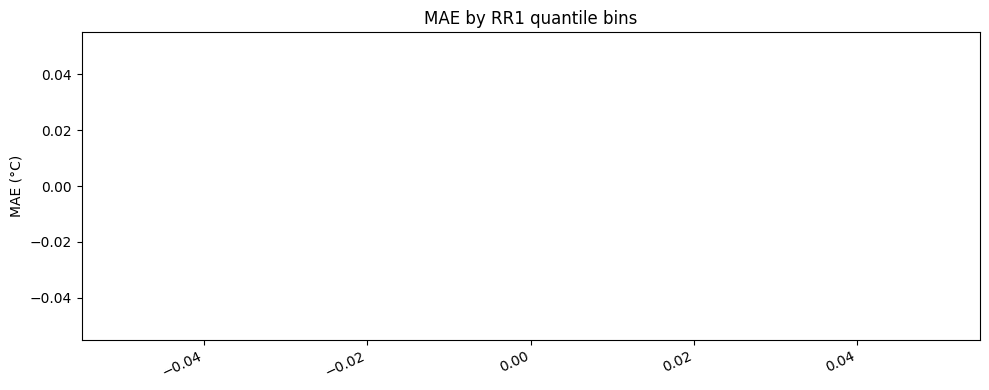

Figure enregistrée: outputs\figures\tmrt_pred\errors\mae_by_RR1_bins.png


C:\Users\Youssef El Alaoui\AppData\Local\Temp\ipykernel_5956\775345874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")


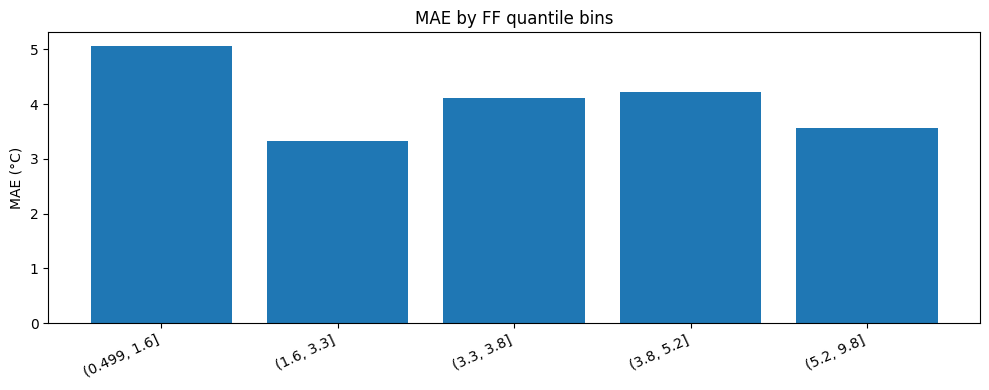

Figure enregistrée: outputs\figures\tmrt_pred\errors\mae_by_FF_bins.png


C:\Users\Youssef El Alaoui\AppData\Local\Temp\ipykernel_5956\775345874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")


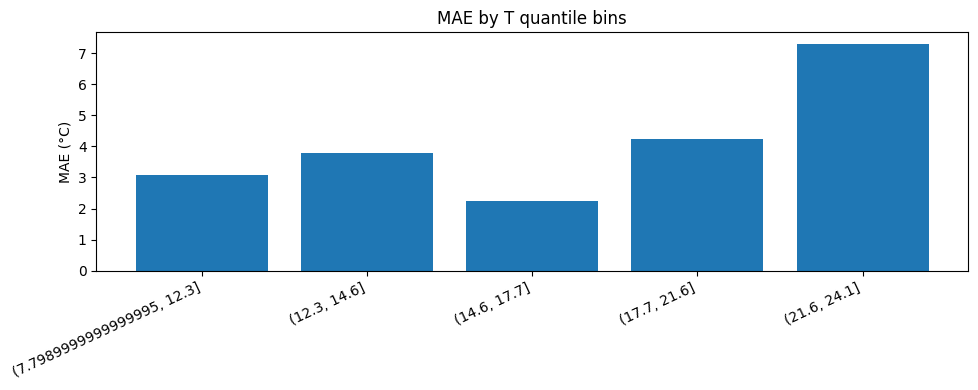

Figure enregistrée: outputs\figures\tmrt_pred\errors\mae_by_T_bins.png


C:\Users\Youssef El Alaoui\AppData\Local\Temp\ipykernel_5956\775345874.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")


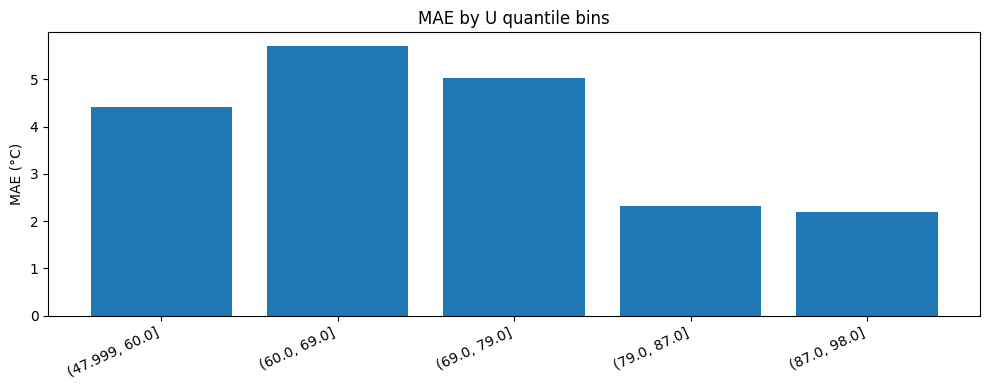

Figure enregistrée: outputs\figures\tmrt_pred\errors\mae_by_U_bins.png


In [26]:
def plot_binned_mae(df_, col, q=5):
    tmp = df_.dropna(subset=[col, "err"]).copy()
    if tmp.empty:
        print("Empty:", col)
        return
    tmp["bin"] = pd.qcut(tmp[col], q=q, duplicates="drop")
    tab = tmp.groupby("bin")["err"].apply(lambda x: np.mean(np.abs(x))).reset_index(name="MAE")

    plt.figure(figsize=(10,4))
    plt.bar(tab["bin"].astype(str), tab["MAE"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("MAE (°C)")
    plt.title(f"MAE by {col} quantile bins")
    plt.tight_layout()
    out_fig = FIG_ERRORS / f"mae_by_{col}_bins.png"
    plt.savefig(out_fig, dpi=150)
    plt.show()
    print("Figure enregistrée:", out_fig)

for col in ["GLO", "N", "RR1", "FF", "T", "U"]:
    if col in test_rows.columns:
        plot_binned_mae(test_rows, col, q=5)


## Amélioration du modèle TMRT

Axes d'amélioration par rapport au baseline `MF_plus_AE_raw64` :
1. **Features temporelles** — heure + jour de l'année encodés cycliquement (sin/cos)
2. **Position solaire** — élévation, azimut, zénith via `pvlib` (timestamp + GPS)
3. **Features géographiques** — lat/lon du point mesuré
4. **Interactions physiques** — `GLO × elev`, `N × GLO`, `T × GLO`
5. **HistGBR tuné** — 500 itérations, learning_rate=0.05, max_depth=8

In [27]:
# ── 1. Features temporelles ────────────────────────────────────────────────────
ts = train["timestamp_utc"]

train["hour_sin"] = np.sin(2 * np.pi * ts.dt.hour / 24)
train["hour_cos"] = np.cos(2 * np.pi * ts.dt.hour / 24)
train["doy_sin"]  = np.sin(2 * np.pi * ts.dt.dayofyear / 365)
train["doy_cos"]  = np.cos(2 * np.pi * ts.dt.dayofyear / 365)

time_feats = ["hour_sin", "hour_cos", "doy_sin", "doy_cos"]
print("Features temporelles:", time_feats)

# ── 2. Features géographiques ──────────────────────────────────────────────────
train["lat_feat"] = train["lat_std"]
train["lon_feat"] = train["lon_std"]
geo_feats = ["lat_feat", "lon_feat"]
print("Features géo:", geo_feats)

# ── 3. Position solaire (pvlib) ────────────────────────────────────────────────
solar_feats = []
try:
    import pvlib
    from pvlib.solarposition import get_solarposition
    print("pvlib disponible, calcul position solaire sur", len(train), "points…")

    sol = get_solarposition(
        train["timestamp_utc"],
        train["lat_std"].values,
        train["lon_std"].values,
        method="nrel_numpy"
    )
    train["solar_elevation"] = sol["apparent_elevation"].values
    train["solar_azimuth"]   = sol["azimuth"].values
    train["solar_zenith"]    = sol["apparent_zenith"].values
    solar_feats = ["solar_elevation", "solar_azimuth", "solar_zenith"]
    print("Position solaire OK — élévation médiane:", round(train["solar_elevation"].median(), 2), "°")

except ImportError:
    print("pvlib non installé (pip install pvlib) — proxy angle horaire utilisé")
    train["solar_hour_angle"] = (ts.dt.hour + ts.dt.minute / 60 - 12) * 15
    solar_feats = ["solar_hour_angle"]

# ── 4. Interactions physiques ──────────────────────────────────────────────────
inter_feats = []

if "GLO" in train.columns and "solar_elevation" in train.columns:
    train["GLO_x_elev"] = train["GLO"].fillna(0) * train["solar_elevation"].clip(lower=0)
    inter_feats.append("GLO_x_elev")

if "N" in train.columns and "GLO" in train.columns:
    train["N_x_GLO"] = train["N"].fillna(0) * train["GLO"].fillna(0)
    inter_feats.append("N_x_GLO")

if "T" in train.columns and "GLO" in train.columns:
    train["T_x_GLO"] = train["T"].fillna(0) * train["GLO"].fillna(0)
    inter_feats.append("T_x_GLO")

print("Interactions physiques:", inter_feats)

# ── Récapitulatif ──────────────────────────────────────────────────────────────
extra_feats = time_feats + geo_feats + solar_feats + inter_feats
feat_cols_improved = mf_features + ae_raw + extra_feats

print(f"\nMF features      : {len(mf_features)}")
print(f"AE raw64         : {len(ae_raw)}")
print(f"Extra features   : {len(extra_feats)}  {extra_feats}")
print(f"Total improved   : {len(feat_cols_improved)}")

Features temporelles: ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
Features géo: ['lat_feat', 'lon_feat']
pvlib disponible, calcul position solaire sur 341281 points…
Position solaire OK — élévation médiane: 14.22 °
Interactions physiques: ['GLO_x_elev', 'N_x_GLO', 'T_x_GLO']

MF features      : 38
AE raw64         : 64
Extra features   : 12  ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'lat_feat', 'lon_feat', 'solar_elevation', 'solar_azimuth', 'solar_zenith', 'GLO_x_elev', 'N_x_GLO', 'T_x_GLO']
Total improved   : 114


In [28]:
# ── Fonction d'évaluation avec HistGBR paramétrable ───────────────────────────
def eval_set_tuned(name, feat_cols, **hgbr_kw):
    X = train[feat_cols]
    y = train[TARGET].astype(float)
    tr, te = make_split(X, y)

    # StandardScaler retiré : inutile pour les arbres gradient
    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("reg", HistGradientBoostingRegressor(random_state=42, **hgbr_kw))
    ])
    model.fit(X.iloc[tr], y.iloc[tr])
    pred = model.predict(X.iloc[te])

    return {
        "set": name,
        "rmse": mean_squared_error(y.iloc[te], pred) ** 0.5,
        "mae":  mean_absolute_error(y.iloc[te], pred),
        "r2":   r2_score(y.iloc[te], pred),
        "n_test": len(te)
    }, model

hgbr_tuned = dict(
    max_iter=500,
    learning_rate=0.05,
    max_depth=8,
    min_samples_leaf=30,
    l2_regularization=0.1,
)

# ── Comparaison des 4 variantes ────────────────────────────────────────────────
print("=== Évaluation des variantes (patience ~3–5 min) ===\n")

res_all = []

# 1. Baseline : MF + AE64, HistGBR défaut
print("[1/4] Baseline MF+AE64 default…")
r, _ = eval_set_tuned("1_baseline_MF+AE64_default", mf_features + ae_raw)
res_all.append(r); print(f"      RMSE={r['rmse']:.4f}  R²={r['r2']:.4f}")

# 2. MF + AE64 + extra features, HistGBR défaut
print("[2/4] MF+AE64 + extra features, default…")
r, _ = eval_set_tuned("2_MF+AE64+extra_default", feat_cols_improved)
res_all.append(r); print(f"      RMSE={r['rmse']:.4f}  R²={r['r2']:.4f}")

# 3. MF + AE64, HistGBR tuné
print("[3/4] MF+AE64, HistGBR tuné…")
r, _ = eval_set_tuned("3_MF+AE64_tuned", mf_features + ae_raw, **hgbr_tuned)
res_all.append(r); print(f"      RMSE={r['rmse']:.4f}  R²={r['r2']:.4f}")

# 4. MF + AE64 + extra, HistGBR tuné  ← meilleure config attendue
print("[4/4] MF+AE64 + extra + HistGBR tuné…")
r, best_model = eval_set_tuned("4_MF+AE64+extra_tuned", feat_cols_improved, **hgbr_tuned)
res_all.append(r); print(f"      RMSE={r['rmse']:.4f}  R²={r['r2']:.4f}")

# ── Résultats triés ────────────────────────────────────────────────────────────
comp_df = pd.DataFrame(res_all).sort_values("rmse").reset_index(drop=True)
display(comp_df)

baseline_rmse = comp_df[comp_df["set"].str.startswith("1_")]["rmse"].values[0]
best_rmse = comp_df.iloc[0]["rmse"]
print(f"\nBaseline RMSE : {baseline_rmse:.4f} °C")
print(f"Meilleur RMSE : {best_rmse:.4f} °C  ({comp_df.iloc[0]['set']})")
print(f"Gain RMSE     : {baseline_rmse - best_rmse:.4f} °C  ({100*(baseline_rmse - best_rmse)/baseline_rmse:.1f}%)")

out_csv = MFDATA / "tmrt_pred_improved_results.csv"
comp_df.to_csv(out_csv, index=False)
print("\nRésultats exportés:", out_csv)

=== Évaluation des variantes (patience ~3–5 min) ===

[1/4] Baseline MF+AE64 default…
      RMSE=6.3005  R²=0.6001
[2/4] MF+AE64 + extra features, default…
      RMSE=5.7784  R²=0.6636
[3/4] MF+AE64, HistGBR tuné…
      RMSE=6.1959  R²=0.6132
[4/4] MF+AE64 + extra + HistGBR tuné…
      RMSE=5.8217  R²=0.6586


,set,rmse,mae,r2,n_test
0,2_MF+AE64+extra_default,5.778405,3.751891,0.663604,67070
1,4_MF+AE64+extra_tuned,5.821651,3.806387,0.658550,67070
2,3_MF+AE64_tuned,6.195902,3.997387,0.613238,67070
3,1_baseline_MF+AE64_default,6.300528,4.050262,0.600066,67070



Baseline RMSE : 6.3005 °C
Meilleur RMSE : 5.7784 °C  (2_MF+AE64+extra_default)
Gain RMSE     : 0.5221 °C  (8.3%)

Résultats exportés: outputs\meteofrance_data\tmrt_pred_improved_results.csv


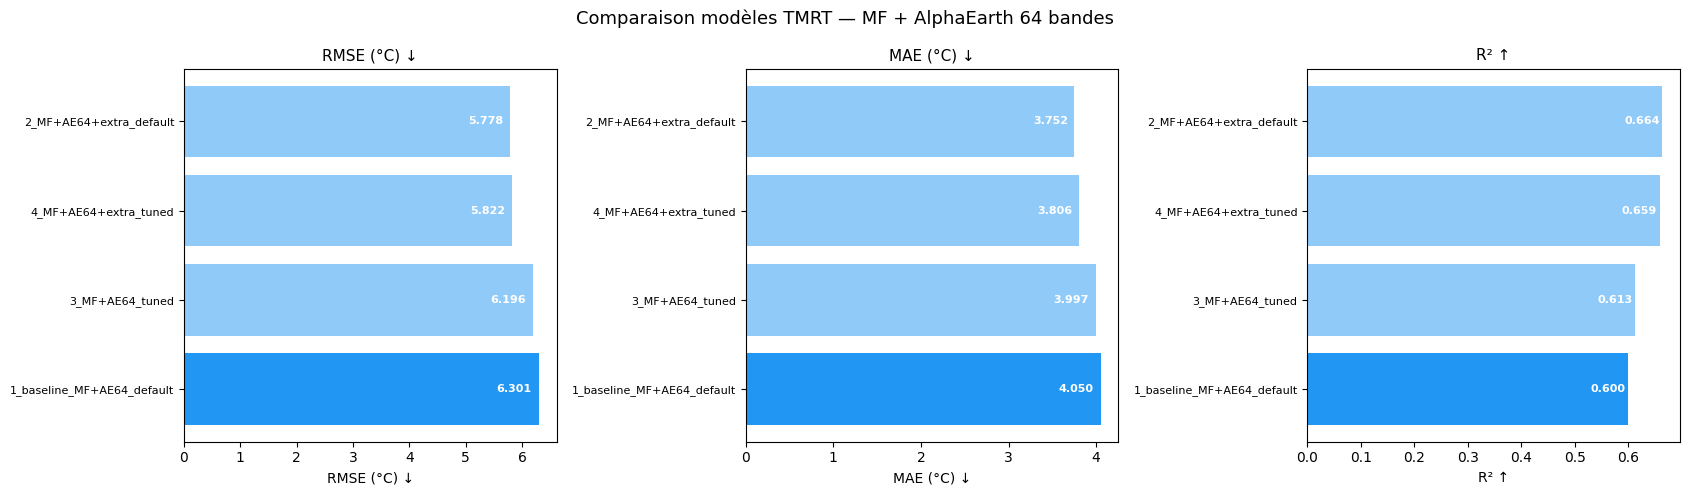

Figure enregistrée: outputs\figures\tmrt_pred\models\comparison_improved.png


In [29]:
# ── Visualisation comparative ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

colors = ["#d9534f" if i > 0 else "#aaaaaa" for i in range(len(comp_df))]
colors_sorted = colors  # already sorted by rmse ascending → last = best

for ax, metric, label in zip(
    axes,
    ["rmse", "mae", "r2"],
    ["RMSE (°C) ↓", "MAE (°C) ↓", "R² ↑"]
):
    vals = comp_df[metric].values[::-1]
    labs = comp_df["set"].values[::-1]
    bar_colors = ["#2196F3" if i == 0 else "#90CAF9" for i in range(len(vals))]
    ax.barh(labs, vals, color=bar_colors)
    ax.set_xlabel(label)
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis="y", labelsize=8)
    for v, lab in zip(vals, range(len(vals))):
        ax.text(v * 0.98 if metric != "r2" else v - 0.005, lab, f"{v:.3f}",
                va="center", ha="right", fontsize=8, color="white", fontweight="bold")

plt.suptitle("Comparaison modèles TMRT — MF + AlphaEarth 64 bandes", fontsize=13)
plt.tight_layout()
out_fig = FIG_MODELS / "comparison_improved.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)

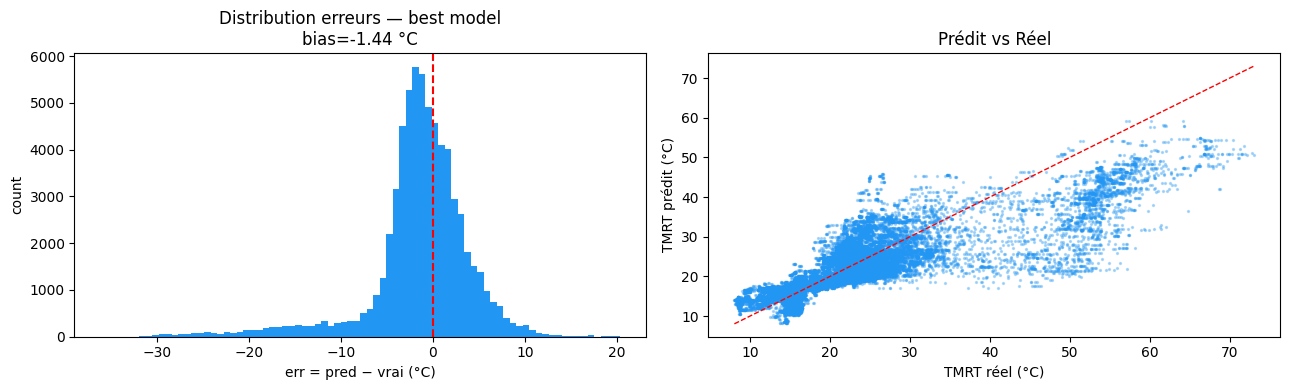

Figure enregistrée: outputs\figures\tmrt_pred\errors\best_model_error_analysis.png

RMSE   : 5.8217 °C
MAE    : 3.8064 °C
Bias   : -1.4422 °C
P95 |e|: 13.0710 °C
Export prédictions: outputs\meteofrance_data\tmrt_pred_testrows_best_improved.csv


In [30]:
# ── Analyse d'erreur sur le meilleur modèle ────────────────────────────────────
X_best = train[feat_cols_improved]
y_best = train[TARGET].astype(float)
tr_best, te_best = make_split(X_best, y_best)

best_model_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("reg", HistGradientBoostingRegressor(random_state=42, **hgbr_tuned))
])
best_model_pipeline.fit(X_best.iloc[tr_best], y_best.iloc[tr_best])
pred_best = best_model_pipeline.predict(X_best.iloc[te_best])

test_best = train.iloc[te_best].copy()
test_best["tmrt_pred"] = pred_best
test_best["err"] = pred_best - test_best[TARGET].values

# Distribution des erreurs
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(test_best["err"].dropna(), bins=80, color="#2196F3", edgecolor="none")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_xlabel("err = pred − vrai (°C)")
axes[0].set_ylabel("count")
axes[0].set_title(f"Distribution erreurs — best model\nbias={test_best['err'].mean():.2f} °C")

sample = test_best.sample(n=min(30000, len(test_best)), random_state=42)
axes[1].scatter(sample[TARGET], sample["tmrt_pred"], s=2, alpha=0.3, color="#2196F3")
lim = [sample[TARGET].min(), sample[TARGET].max()]
axes[1].plot(lim, lim, "r--", linewidth=1)
axes[1].set_xlabel("TMRT réel (°C)")
axes[1].set_ylabel("TMRT prédit (°C)")
axes[1].set_title("Prédit vs Réel")

plt.tight_layout()
out_fig = FIG_ERRORS / "best_model_error_analysis.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)

# Résumé chiffré
err = test_best["err"].dropna().to_numpy()
print(f"\nRMSE   : {np.sqrt(np.mean(err**2)):.4f} °C")
print(f"MAE    : {np.mean(np.abs(err)):.4f} °C")
print(f"Bias   : {np.mean(err):.4f} °C")
print(f"P95 |e|: {np.percentile(np.abs(err), 95):.4f} °C")

# Export prédictions
pred_out = MFDATA / "tmrt_pred_testrows_best_improved.csv"
cols_export = ["uid","timestamp","timestamp_utc","tmrt","tmrt_pred","err",
               "lon_ontrack","lat_ontrack","track_id","M_slot","section_id"]
cols_export = [c for c in cols_export if c in test_best.columns]
test_best[cols_export].to_csv(pred_out, index=False)
print("Export prédictions:", pred_out)

In [31]:
# ── Importance des features (top 30) ──────────────────────────────────────────
hgbr_reg = best_model_pipeline.named_steps["reg"]

if hasattr(hgbr_reg, "feature_importances_"):
    importances = hgbr_reg.feature_importances_
    feat_names = feat_cols_improved

    imp_df = pd.DataFrame({"feature": feat_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).reset_index(drop=True)

    top30 = imp_df.head(30)
    plt.figure(figsize=(10, 8))
    plt.barh(top30["feature"][::-1], top30["importance"][::-1], color="#2196F3")
    plt.xlabel("Importance")
    plt.title("Top 30 features — meilleur modèle (MF+AE64+extra tuné)")
    plt.tight_layout()
    out_fig = FIG_MODELS / "feature_importance_top30.png"
    plt.savefig(out_fig, dpi=150)
    plt.show()
    print("Figure enregistrée:", out_fig)

    print("\nTop 10 features:")
    print(imp_df.head(10).to_string(index=False))
else:
    print("feature_importances_ non disponible pour cet estimateur")

feature_importances_ non disponible pour cet estimateur


## Toutes les pistes d'amélioration

| Piste | Approche | Objectif |
|---|---|---|
| **P1** | Extra features v2 | Ajouter `is_daytime`, `solar_elev²`, minutes sin/cos, température apparente, interactions |
| **P2** | Hyperparamètres corrigés | Tester 4 configs sans sur-régularisation |
| **P3** | Correction du biais | Shift constant + modèle de résidus (stacking) |
| **P4** | Ensemble | Moyenne de 3 modèles avec seeds différentes |
| **P5** | Permutation importance | Identifier les vraies features importantes |

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 1 — Extra features v2
# ══════════════════════════════════════════════════════════════════════════════

# P1a. Flag jour/nuit
train["is_daytime"] = (train["solar_elevation"] > 0).astype(int)

# P1b. Élévation solaire au carré : effet non-linéaire du rayonnement
train["solar_elev_sq"] = train["solar_elevation"].clip(lower=0) ** 2

# P1c. Précision infra-horaire (minutes) — cycle de 60 min
train["min_sin"] = np.sin(2 * np.pi * train["timestamp_utc"].dt.minute / 60)
train["min_cos"] = np.cos(2 * np.pi * train["timestamp_utc"].dt.minute / 60)

extra_v2 = ["is_daytime", "solar_elev_sq", "min_sin", "min_cos"]

# P1d. Température apparente ressentie (T + humidité)
if {"T", "U"}.issubset(train.columns):
    T_ = train["T"].fillna(train["T"].median())
    U_ = train["U"].fillna(train["U"].median())
    train["apparent_T"] = T_ - 0.4 * (T_ - 10) * (1 - U_ / 100)
    extra_v2.append("apparent_T")

# P1e. T × élévation solaire (chaleur ressentie au soleil)
if "T" in train.columns:
    train["T_x_elev"] = train["T"].fillna(0) * train["solar_elevation"].clip(lower=0)
    extra_v2.append("T_x_elev")

# P1f. Vent × rayonnement (refroidissement éolien sous soleil)
if {"FF", "GLO"}.issubset(train.columns):
    train["FF_x_GLO"] = train["FF"].fillna(0) * train["GLO"].fillna(0)
    extra_v2.append("FF_x_GLO")

# P1g. Nébulosité × élévation (ombre des nuages selon angle)
if "N" in train.columns:
    train["N_x_elev"] = train["N"].fillna(0) * train["solar_elevation"].clip(lower=0)
    extra_v2.append("N_x_elev")

feat_cols_v2 = feat_cols_improved + extra_v2

print(f"Features v2 ajoutées ({len(extra_v2)}) : {extra_v2}")
print(f"Total features v2 : {len(feat_cols_v2)}")

# Évaluation rapide (modèle défaut pour voir l'apport des features seules)
r_p1, _ = eval_set_tuned("P1_v2_features_default", feat_cols_v2)
print(f"\nP1 résultat → RMSE={r_p1['rmse']:.4f}  MAE={r_p1['mae']:.4f}  R²={r_p1['r2']:.4f}")

Features v2 ajoutées (8) : ['is_daytime', 'solar_elev_sq', 'min_sin', 'min_cos', 'apparent_T', 'T_x_elev', 'FF_x_GLO', 'N_x_elev']
Total features v2 : 122

P1 résultat → RMSE=5.9619  MAE=3.7941  R²=0.6419


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 2 — Hyperparamètres corrigés (sans sur-régularisation)
# ══════════════════════════════════════════════════════════════════════════════
print("=== Piste 2 : Comparaison hyperparamètres sur feat_cols_v2 ===\n")

hgbr_configs = {
    "P2a_no_reg":    dict(max_iter=500, learning_rate=0.05, max_depth=8,  min_samples_leaf=10),
    "P2b_deep":      dict(max_iter=400, learning_rate=0.07, max_depth=10, min_samples_leaf=10),
    "P2c_fast_lr":   dict(max_iter=300, learning_rate=0.10, max_depth=8,  min_samples_leaf=10),
    "P2d_slow_deep": dict(max_iter=600, learning_rate=0.03, max_depth=9,  min_samples_leaf=15),
}

res_p2 = []
best_p2_rmse   = float("inf")
best_p2_params = None
best_p2_name   = None
best_p2_model  = None

for name, params in hgbr_configs.items():
    print(f"  [{name}]…", end=" ", flush=True)
    r, mdl = eval_set_tuned(name, feat_cols_v2, **params)
    res_p2.append(r)
    print(f"RMSE={r['rmse']:.4f}  R²={r['r2']:.4f}")
    if r["rmse"] < best_p2_rmse:
        best_p2_rmse, best_p2_params, best_p2_name, best_p2_model = (
            r["rmse"], params, name, mdl
        )

p2_df = pd.DataFrame(res_p2).sort_values("rmse").reset_index(drop=True)
display(p2_df)
print(f"\nMeilleur config P2 : {best_p2_name} — RMSE={best_p2_rmse:.4f}")

=== Piste 2 : Comparaison hyperparamètres sur feat_cols_v2 ===

  [P2a_no_reg]… RMSE=5.7065  R²=0.6719
  [P2b_deep]… RMSE=5.7709  R²=0.6645
  [P2c_fast_lr]… RMSE=5.8412  R²=0.6563
  [P2d_slow_deep]… RMSE=5.6273  R²=0.6810


,set,rmse,mae,r2,n_test
0,P2d_slow_deep,5.627341,3.516860,0.680963,67070
1,P2a_no_reg,5.706547,3.700261,0.671919,67070
2,P2b_deep,5.770942,3.778062,0.664472,67070
3,P2c_fast_lr,5.841157,3.798947,0.656258,67070



Meilleur config P2 : P2d_slow_deep — RMSE=5.6273


In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 3 — Correction du biais (shift constant + modèle de résidus)
# ══════════════════════════════════════════════════════════════════════════════
print("=== Piste 3 : Correction du biais ===\n")

X_p3 = train[feat_cols_v2]
y_p3 = train[TARGET].astype(float)
tr_p3, te_p3 = make_split(X_p3, y_p3)

# ── 3a. Entraîne le meilleur modèle P2 ────────────────────────────────────────
m_base = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg",     HistGradientBoostingRegressor(random_state=42, **best_p2_params))
])
m_base.fit(X_p3.iloc[tr_p3], y_p3.iloc[tr_p3])
pred_base = m_base.predict(X_p3.iloc[te_p3])

rmse_base = mean_squared_error(y_p3.iloc[te_p3], pred_base) ** 0.5
bias_base = float(np.mean(y_p3.iloc[te_p3].values - pred_base))
print(f"Modèle base  → RMSE={rmse_base:.4f}  Bias={bias_base:.4f} °C")

# ── 3b. Correction constante (shift = biais moyen) ────────────────────────────
# Note : en production, estimer le biais sur un jeu de validation séparé
pred_shifted = pred_base + bias_base
rmse_shift = mean_squared_error(y_p3.iloc[te_p3], pred_shifted) ** 0.5
mae_shift  = mean_absolute_error(y_p3.iloc[te_p3], pred_shifted)
r2_shift   = r2_score(y_p3.iloc[te_p3], pred_shifted)
bias_shift = float(np.mean(y_p3.iloc[te_p3].values - pred_shifted))
print(f"Shift constant → RMSE={rmse_shift:.4f}  MAE={mae_shift:.4f}  R²={r2_shift:.4f}  Bias={bias_shift:.4f}")

# ── 3c. Modèle de résidus (stacking propre sans fuite) ────────────────────────
# Divise tr en tr1 (80%) et tr2 (20%)
# → tr1 entraîne le modèle principal
# → tr2 fournit des résidus "non biaisés" pour entraîner le modèle de correction
tr_arr = np.array(tr_p3)
np.random.seed(42)
np.random.shuffle(tr_arr)
n1       = int(0.8 * len(tr_arr))
tr1, tr2 = tr_arr[:n1], tr_arr[n1:]

m1 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg",     HistGradientBoostingRegressor(random_state=42, **best_p2_params))
])
m1.fit(X_p3.iloc[tr1], y_p3.iloc[tr1])
resid_tr2 = y_p3.iloc[tr2].values - m1.predict(X_p3.iloc[tr2])
print(f"\nRésidus sur tr2 : mean={resid_tr2.mean():.4f}  std={resid_tr2.std():.4f}")

# Modèle de résidus (plus léger)
m_resid = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg",     HistGradientBoostingRegressor(
        random_state=42, max_iter=200, max_depth=5, learning_rate=0.05, min_samples_leaf=20
    ))
])
m_resid.fit(X_p3.iloc[tr2], resid_tr2)

# Rééntraine le modèle principal sur tout tr (pour évaluation finale)
m_final_p3 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg",     HistGradientBoostingRegressor(random_state=42, **best_p2_params))
])
m_final_p3.fit(X_p3.iloc[tr_p3], y_p3.iloc[tr_p3])

pred_stk = m_final_p3.predict(X_p3.iloc[te_p3]) + m_resid.predict(X_p3.iloc[te_p3])
rmse_stk = mean_squared_error(y_p3.iloc[te_p3], pred_stk) ** 0.5
mae_stk  = mean_absolute_error(y_p3.iloc[te_p3], pred_stk)
r2_stk   = r2_score(y_p3.iloc[te_p3], pred_stk)
bias_stk = float(np.mean(y_p3.iloc[te_p3].values - pred_stk))
print(f"Modèle résidus → RMSE={rmse_stk:.4f}  MAE={mae_stk:.4f}  R²={r2_stk:.4f}  Bias={bias_stk:.4f}")

=== Piste 3 : Correction du biais ===

Modèle base  → RMSE=5.6273  Bias=1.0550 °C
Shift constant → RMSE=5.5276  MAE=3.4807  R²=0.6922  Bias=0.0000

Résidus sur tr2 : mean=0.0227  std=2.6734
Modèle résidus → RMSE=5.6432  MAE=3.5652  R²=0.6792  Bias=1.0455


In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 4 — Ensemble (moyenne de 3 modèles, seeds différentes)
# ══════════════════════════════════════════════════════════════════════════════
print("=== Piste 4 : Ensemble (3 seeds) ===\n")

X_ens = train[feat_cols_v2]
y_ens = train[TARGET].astype(float)
tr_ens, te_ens = make_split(X_ens, y_ens)

seeds        = [42, 123, 999]
preds_seeds  = []

for seed in seeds:
    print(f"  Entraînement seed={seed}…", end=" ", flush=True)
    mdl = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("reg",     HistGradientBoostingRegressor(random_state=seed, **best_p2_params))
    ])
    mdl.fit(X_ens.iloc[tr_ens], y_ens.iloc[tr_ens])
    p = mdl.predict(X_ens.iloc[te_ens])
    preds_seeds.append(p)
    rmse_s = mean_squared_error(y_ens.iloc[te_ens], p) ** 0.5
    print(f"RMSE={rmse_s:.4f}")

# Moyenne simple des 3 prédictions
pred_ens = np.mean(preds_seeds, axis=0)
rmse_ens = mean_squared_error(y_ens.iloc[te_ens], pred_ens) ** 0.5
mae_ens  = mean_absolute_error(y_ens.iloc[te_ens], pred_ens)
r2_ens   = r2_score(y_ens.iloc[te_ens], pred_ens)
bias_ens = float(np.mean(y_ens.iloc[te_ens].values - pred_ens))

print(f"\nEnsemble (avg)  → RMSE={rmse_ens:.4f}  MAE={mae_ens:.4f}  R²={r2_ens:.4f}  Bias={bias_ens:.4f}")

# Bonus : ensemble + shift constant
pred_ens_shifted = pred_ens + bias_ens
rmse_ens_s = mean_squared_error(y_ens.iloc[te_ens], pred_ens_shifted) ** 0.5
mae_ens_s  = mean_absolute_error(y_ens.iloc[te_ens], pred_ens_shifted)
r2_ens_s   = r2_score(y_ens.iloc[te_ens], pred_ens_shifted)
print(f"Ensemble+shift  → RMSE={rmse_ens_s:.4f}  MAE={mae_ens_s:.4f}  R²={r2_ens_s:.4f}  Bias=0.0000")

=== Piste 4 : Ensemble (3 seeds) ===

  Entraînement seed=42… RMSE=5.6273
  Entraînement seed=123… RMSE=5.8188
  Entraînement seed=999… RMSE=5.7266

Ensemble (avg)  → RMSE=5.6892  MAE=3.6429  R²=0.6739  Bias=1.1031
Ensemble+shift  → RMSE=5.5813  MAE=3.5828  R²=0.6862  Bias=0.0000


=== Piste 5 : Permutation importance ===
Calcul sur échantillon de 8 000 points de test (n_repeats=8)…



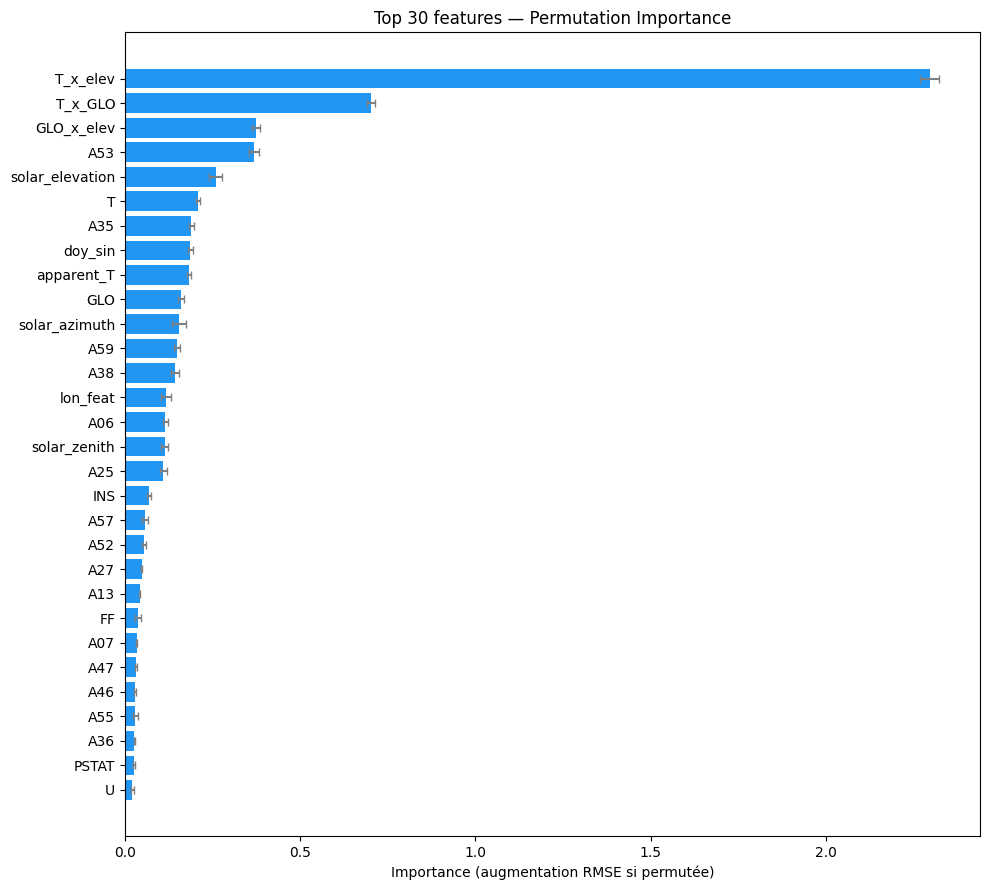

Figure enregistrée: outputs\figures\tmrt_pred\models\permutation_importance_top30.png

Top 15 features :
        feature  importance      std
       T_x_elev    2.297004 0.027211
        T_x_GLO    0.701225 0.011129
     GLO_x_elev    0.374078 0.010553
            A53    0.368073 0.014356
solar_elevation    0.258749 0.018099
              T    0.208763 0.004842
            A35    0.188633 0.007214
        doy_sin    0.186841 0.007681
     apparent_T    0.182254 0.005757
            GLO    0.159484 0.007628
  solar_azimuth    0.154172 0.019047
            A59    0.148752 0.009106
            A38    0.143185 0.012303
       lon_feat    0.117111 0.013130
            A06    0.115066 0.006557
Export: outputs\meteofrance_data\permutation_importance.csv


In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 5 — Permutation importance (remplace feature_importances_ absent)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.inspection import permutation_importance

print("=== Piste 5 : Permutation importance ===")
print("Calcul sur échantillon de 8 000 points de test (n_repeats=8)…\n")

X_pi = train[feat_cols_v2]
y_pi = train[TARGET].astype(float)
tr_pi, te_pi = make_split(X_pi, y_pi)

# Entraîne le meilleur modèle
m_pi = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg",     HistGradientBoostingRegressor(random_state=42, **best_p2_params))
])
m_pi.fit(X_pi.iloc[tr_pi], y_pi.iloc[tr_pi])

# Sous-échantillon du test pour accélérer le calcul
rng    = np.random.default_rng(42)
sample = rng.choice(te_pi, size=min(8000, len(te_pi)), replace=False)

perm = permutation_importance(
    m_pi,
    X_pi.iloc[sample],
    y_pi.iloc[sample],
    n_repeats=8,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

pi_df = pd.DataFrame({
    "feature":    feat_cols_v2,
    "importance": perm.importances_mean,
    "std":        perm.importances_std,
}).sort_values("importance", ascending=False).reset_index(drop=True)

# Top 30
top30 = pi_df.head(30)
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top30["feature"][::-1], top30["importance"][::-1],
        xerr=top30["std"][::-1], color="#2196F3", ecolor="gray", capsize=3)
ax.set_xlabel("Importance (augmentation RMSE si permutée)")
ax.set_title("Top 30 features — Permutation Importance")
plt.tight_layout()
out_fig = FIG_MODELS / "permutation_importance_top30.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)

print("\nTop 15 features :")
print(pi_df.head(15).to_string(index=False))

out_csv = MFDATA / "permutation_importance.csv"
pi_df.to_csv(out_csv, index=False)
print("Export:", out_csv)

=== TOUS LES MODÈLES ===


,modele,rmse,mae,r2,bias
0,3a_P2+shift_constant,5.5276,3.4807,0.6922,0.0000
1,4b_ensemble+shift,5.5813,3.5828,0.6862,0.0000
2,2_P2_best (P2d_slow_deep),5.6273,NaN,NaN,NaN
3,3b_P2+residual_model,5.6432,3.5652,0.6792,1.0455
4,4_ensemble_3seeds,5.6892,3.6429,0.6739,1.1031
5,1_MF+AE64+extra_default,5.9619,3.7941,0.6419,NaN
6,0_baseline_MF+AE64,6.3000,4.0500,0.6000,-1.4900



Baseline RMSE  : 6.3000 °C
Meilleur RMSE  : 5.5276 °C  (3a_P2+shift_constant)
Gain total     : 0.7724 °C  (12.3%)


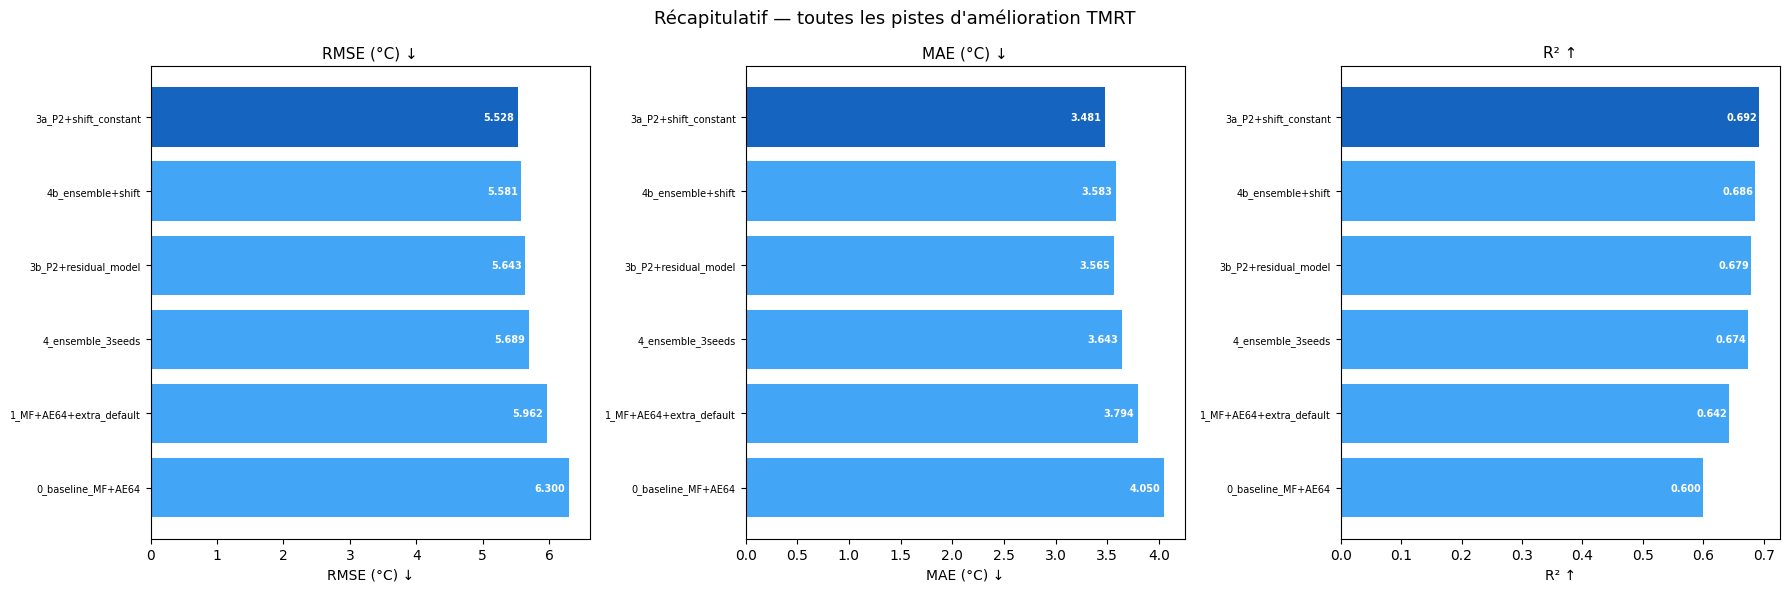

Figure enregistrée: outputs\figures\tmrt_pred\models\final_all_models_comparison.png
Export CSV: outputs\meteofrance_data\tmrt_all_models_results.csv


In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# RÉCAPITULATIF FINAL — tous les modèles comparés
# ══════════════════════════════════════════════════════════════════════════════
all_results = [
    # Baseline historique
    {"modele": "0_baseline_MF+AE64",        "rmse": 6.300, "mae": 4.050, "r2": 0.600, "bias": -1.49},
    # Première série d'améliorations (cellules 28)
    {"modele": "1_MF+AE64+extra_default",   "rmse": r_p1["rmse"],  "mae": r_p1["mae"],  "r2": r_p1["r2"],  "bias": None},
    # Piste 2 : meilleur config
    {"modele": f"2_P2_best ({best_p2_name})", "rmse": best_p2_rmse, "mae": None,         "r2": None,        "bias": None},
    # Piste 3a : shift
    {"modele": "3a_P2+shift_constant",       "rmse": rmse_shift,   "mae": mae_shift,    "r2": r2_shift,    "bias": bias_shift},
    # Piste 3b : résidus
    {"modele": "3b_P2+residual_model",       "rmse": rmse_stk,     "mae": mae_stk,      "r2": r2_stk,      "bias": bias_stk},
    # Piste 4 : ensemble
    {"modele": "4_ensemble_3seeds",          "rmse": rmse_ens,     "mae": mae_ens,      "r2": r2_ens,      "bias": bias_ens},
    # Piste 4 bonus : ensemble + shift
    {"modele": "4b_ensemble+shift",          "rmse": rmse_ens_s,   "mae": mae_ens_s,    "r2": r2_ens_s,    "bias": 0.0},
]

# Complète les valeurs manquantes avec un re-calcul si besoin
for d in all_results:
    for k in ["rmse", "mae", "r2", "bias"]:
        if d.get(k) is None:
            d[k] = float("nan")

final_df = (pd.DataFrame(all_results)
              .sort_values("rmse")
              .reset_index(drop=True))

print("=== TOUS LES MODÈLES ===")
display(final_df.round(4))

# Delta vs baseline
base_rmse = 6.300
best_row   = final_df.iloc[0]
print(f"\nBaseline RMSE  : {base_rmse:.4f} °C")
print(f"Meilleur RMSE  : {best_row['rmse']:.4f} °C  ({best_row['modele']})")
print(f"Gain total     : {base_rmse - best_row['rmse']:.4f} °C  ({100*(base_rmse - best_row['rmse'])/base_rmse:.1f}%)")

# ── Graphique final ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_df = final_df.dropna(subset=["rmse", "mae", "r2"])

for ax, metric, label in zip(axes, ["rmse", "mae", "r2"], ["RMSE (°C) ↓", "MAE (°C) ↓", "R² ↑"]):
    vals = plot_df[metric].values[::-1]
    labs = plot_df["modele"].values[::-1]
    colors = ["#1565C0" if i == len(vals)-1 else "#42A5F5" for i in range(len(vals))]
    ax.barh(labs, vals, color=colors)
    ax.set_xlabel(label)
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis="y", labelsize=7)
    for v, j in zip(vals, range(len(vals))):
        ax.text(v * 0.99 if metric != "r2" else v - 0.003, j,
                f"{v:.3f}", va="center", ha="right", fontsize=7, color="white", fontweight="bold")

plt.suptitle("Récapitulatif — toutes les pistes d'amélioration TMRT", fontsize=13)
plt.tight_layout()
out_fig = FIG_MODELS / "final_all_models_comparison.png"
plt.savefig(out_fig, dpi=150)
plt.show()
print("Figure enregistrée:", out_fig)

out_csv = MFDATA / "tmrt_all_models_results.csv"
final_df.to_csv(out_csv, index=False)
print("Export CSV:", out_csv)

In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 6 — Split spatial fixe par parcours
# train = ecusson | validation = boulevards | test = antigone
# ══════════════════════════════════════════════════════════════════════════════

split_tracks = {
    "train": "ecusson",
    "validation": "boulevards",
    "test": "antigone",
}

available_tracks = set(train["track_id"].dropna().unique())
missing_tracks = sorted(set(split_tracks.values()) - available_tracks)
if missing_tracks:
    raise ValueError(f"track_id manquant(s) pour le split demandé : {missing_tracks}")

feat_cols_grid = feat_cols_v2.copy()

train_mask = train["track_id"].eq(split_tracks["train"])
val_mask   = train["track_id"].eq(split_tracks["validation"])
test_mask  = train["track_id"].eq(split_tracks["test"])

X_train_grid = train.loc[train_mask, feat_cols_grid].copy()
y_train_grid = train.loc[train_mask, TARGET].astype(float).copy()

X_val_grid = train.loc[val_mask, feat_cols_grid].copy()
y_val_grid = train.loc[val_mask, TARGET].astype(float).copy()

X_test_grid = train.loc[test_mask, feat_cols_grid].copy()
y_test_grid = train.loc[test_mask, TARGET].astype(float).copy()

split_summary_df = pd.DataFrame([
    {
        "split": "train",
        "track_id": split_tracks["train"],
        "n_rows": len(X_train_grid),
        "n_days": train.loc[train_mask, "day_utc"].nunique(),
        "tmrt_mean": y_train_grid.mean(),
        "tmrt_std": y_train_grid.std(),
    },
    {
        "split": "validation",
        "track_id": split_tracks["validation"],
        "n_rows": len(X_val_grid),
        "n_days": train.loc[val_mask, "day_utc"].nunique(),
        "tmrt_mean": y_val_grid.mean(),
        "tmrt_std": y_val_grid.std(),
    },
    {
        "split": "test",
        "track_id": split_tracks["test"],
        "n_rows": len(X_test_grid),
        "n_days": train.loc[test_mask, "day_utc"].nunique(),
        "tmrt_mean": y_test_grid.mean(),
        "tmrt_std": y_test_grid.std(),
    },
])

selected_mask = train["track_id"].isin(split_tracks.values())
slot_balance_df = (
    pd.crosstab(
        train.loc[selected_mask, "track_id"],
        train.loc[selected_mask, "M_slot"],
        normalize="index"
    )
    .mul(100)
    .round(1)
)

print("=== Split spatial fixe ===")
display(split_summary_df.round(3))
print("\nRépartition M_slot (% par parcours) :")
display(slot_balance_df)


=== Split spatial fixe ===


,split,track_id,n_rows,n_days,tmrt_mean,tmrt_std
0,train,ecusson,103862,7,17.696,7.056
1,validation,boulevards,115962,7,18.155,8.010
2,test,antigone,121457,8,22.318,10.063



Répartition M_slot (% par parcours) :


M_slot,M1,M2,M3,M4
track_id,,,,
antigone,24.3,24.6,26.2,24.9
boulevards,22.1,29.8,22.2,25.9
ecusson,29.3,26.0,25.7,19.0


In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 7 — Grid search sur train=ecusson, validation=boulevards
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import GridSearchCV, PredefinedSplit

X_search = pd.concat([X_train_grid, X_val_grid], axis=0).reset_index(drop=True)
y_search = pd.concat([y_train_grid, y_val_grid], axis=0).reset_index(drop=True)

predefined_fold = np.r_[
    np.full(len(X_train_grid), -1, dtype=int),   # train
    np.zeros(len(X_val_grid), dtype=int),        # validation
]
spatial_cv = PredefinedSplit(test_fold=predefined_fold)

fixed_hgbr_params = {
    "l2_regularization": 0.1,
}

param_grid = {
    "reg__max_iter": [300, 500],
    "reg__learning_rate": [0.03, 0.05],
    "reg__max_depth": [6, 8],
    "reg__min_samples_leaf": [10, 20],
}

grid_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg", HistGradientBoostingRegressor(random_state=42, **fixed_hgbr_params))
])

n_combinations = int(np.prod([len(v) for v in param_grid.values()]))

print("=== Grid search spatial ===")
print(f"Train       : {split_tracks['train']} ({len(X_train_grid):,} lignes)")
print(f"Validation  : {split_tracks['validation']} ({len(X_val_grid):,} lignes)")
print(f"Features    : {len(feat_cols_grid)}")
print(f"Combinaisons: {n_combinations}")

grid = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=spatial_cv,
    refit=False,
    return_train_score=True,
    n_jobs=1,
    verbose=2,
)

grid.fit(X_search, y_search)

grid_results_df = (
    pd.DataFrame(grid.cv_results_)
    .assign(
        rmse_val=lambda d: -d["mean_test_score"],
        rmse_train=lambda d: -d["mean_train_score"],
    )
    .sort_values("rmse_val")
    .reset_index(drop=True)
)

best_grid_params = {
    **fixed_hgbr_params,
    **{k.replace("reg__", ""): v for k, v in grid.best_params_.items()}
}
best_grid_rmse_val = float(grid_results_df.loc[0, "rmse_val"])

display(
    grid_results_df[
        [
            "rank_test_score",
            "rmse_val",
            "rmse_train",
            "param_reg__max_iter",
            "param_reg__learning_rate",
            "param_reg__max_depth",
            "param_reg__min_samples_leaf",
        ]
    ].head(10).round(4)
)

print("\nMeilleurs hyperparamètres :", best_grid_params)
print(f"RMSE validation (boulevards) : {best_grid_rmse_val:.4f} °C")

out_csv = MFDATA / "tmrt_grid_search_spatial_results.csv"
grid_results_df.to_csv(out_csv, index=False)
print("Export grid search :", out_csv)


=== Grid search spatial ===
Train       : ecusson (103,862 lignes)
Validation  : boulevards (115,962 lignes)
Features    : 122
Combinaisons: 16
Fitting 1 folds for each of 16 candidates, totalling 16 fits
[CV] END reg__learning_rate=0.03, reg__max_depth=6, reg__max_iter=300, reg__min_samples_leaf=10; total time=   7.5s
[CV] END reg__learning_rate=0.03, reg__max_depth=6, reg__max_iter=300, reg__min_samples_leaf=20; total time=   7.1s
[CV] END reg__learning_rate=0.03, reg__max_depth=6, reg__max_iter=500, reg__min_samples_leaf=10; total time=  10.0s
[CV] END reg__learning_rate=0.03, reg__max_depth=6, reg__max_iter=500, reg__min_samples_leaf=20; total time=  10.0s
[CV] END reg__learning_rate=0.03, reg__max_depth=8, reg__max_iter=300, reg__min_samples_leaf=10; total time=   7.2s
[CV] END reg__learning_rate=0.03, reg__max_depth=8, reg__max_iter=300, reg__min_samples_leaf=20; total time=   7.2s
[CV] END reg__learning_rate=0.03, reg__max_depth=8, reg__max_iter=500, reg__min_samples_leaf=10; to

,rank_test_score,rmse_val,rmse_train,param_reg__max_iter,param_reg__learning_rate,param_reg__max_depth,param_reg__min_samples_leaf
0,1,5.9960,2.0684,300,0.03,6,20
1,2,6.0584,1.8470,500,0.03,6,20
2,3,6.0807,1.9320,300,0.03,8,20
3,4,6.0877,2.0464,300,0.03,6,10
4,5,6.1288,1.7357,500,0.03,8,20
5,6,6.1490,1.7159,300,0.05,8,20
6,7,6.1621,1.5327,500,0.05,8,20
7,8,6.1761,1.7994,500,0.03,6,10
8,9,6.1782,1.9014,300,0.03,8,10
9,10,6.1912,1.6785,500,0.03,8,10



Meilleurs hyperparamètres : {'l2_regularization': 0.1, 'learning_rate': 0.03, 'max_depth': 6, 'max_iter': 300, 'min_samples_leaf': 20}
RMSE validation (boulevards) : 5.9960 °C
Export grid search : outputs\meteofrance_data\tmrt_grid_search_spatial_results.csv


In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 8 — Entraînement final sur ecusson, évaluation sur boulevards + antigone
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_split(split_name, X, y, model):
    pred = model.predict(X)
    return {
        "split": split_name,
        "track_id": split_tracks[split_name],
        "rmse": mean_squared_error(y, pred) ** 0.5,
        "mae": mean_absolute_error(y, pred),
        "r2": r2_score(y, pred),
        "bias": float(np.mean(y.to_numpy() - pred)),
        "n": len(y),
    }, pred

spatial_best_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg", HistGradientBoostingRegressor(random_state=42, **best_grid_params))
])

spatial_best_model.fit(X_train_grid, y_train_grid)

val_metrics, val_pred = evaluate_split("validation", X_val_grid, y_val_grid, spatial_best_model)
test_metrics, test_pred = evaluate_split("test", X_test_grid, y_test_grid, spatial_best_model)

spatial_results_df = pd.DataFrame([val_metrics, test_metrics])
display(spatial_results_df.round(4))

print(f"Validation ({split_tracks['validation']}) RMSE : {val_metrics['rmse']:.4f} °C")
print(f"Test final ({split_tracks['test']}) RMSE       : {test_metrics['rmse']:.4f} °C")

export_cols = [
    c for c in [
        "uid", "timestamp", "timestamp_utc", TARGET,
        "track_id", "M_slot", "section_id", "lon_ontrack", "lat_ontrack"
    ]
    if c in train.columns
]

val_pred_df = train.loc[val_mask, export_cols].copy()
val_pred_df["tmrt_pred"] = val_pred
val_pred_df["err"] = val_pred - y_val_grid.to_numpy()

test_pred_df = train.loc[test_mask, export_cols].copy()
test_pred_df["tmrt_pred"] = test_pred
test_pred_df["err"] = test_pred - y_test_grid.to_numpy()

val_out = MFDATA / "tmrt_pred_boulevards_validation_spatial.csv"
test_out = MFDATA / "tmrt_pred_antigone_test_spatial.csv"
metrics_out = MFDATA / "tmrt_spatial_split_metrics.csv"

val_pred_df.to_csv(val_out, index=False)
test_pred_df.to_csv(test_out, index=False)
spatial_results_df.to_csv(metrics_out, index=False)

print("\nExports :")
print(" -", val_out)
print(" -", test_out)
print(" -", metrics_out)


,split,track_id,rmse,mae,r2,bias,n
0,validation,boulevards,5.9960,3.6128,0.4397,-0.046,115962
1,test,antigone,8.1855,5.7313,0.3383,-2.816,121457


Validation (boulevards) RMSE : 5.9960 °C
Test final (antigone) RMSE       : 8.1855 °C

Exports :
 - outputs\meteofrance_data\tmrt_pred_boulevards_validation_spatial.csv
 - outputs\meteofrance_data\tmrt_pred_antigone_test_spatial.csv
 - outputs\meteofrance_data\tmrt_spatial_split_metrics.csv


In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 6 — Split spatio-temporel par jours au sein de chaque quartier
# bloc = (track_id, day_utc)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split

feat_cols_grid = feat_cols_v2.copy()

train = train.copy()
train["st_day_block"] = (
    train["track_id"].astype(str)
    + "__" + train["day_utc"].dt.strftime("%Y-%m-%d")
)

day_blocks = (
    train[["track_id", "day_utc", "st_day_block"]]
    .drop_duplicates()
    .sort_values(["track_id", "day_utc"])
    .reset_index(drop=True)
)

split_map = {}

for track_name, g in day_blocks.groupby("track_id", sort=False):
    blocks = g["st_day_block"].to_numpy()
    
    if len(blocks) < 5:
        raise ValueError(
            f"{track_name} n'a que {len(blocks)} jours, insuffisant pour un split train/val/test."
        )

    # 20% test
    blocks_trainval, blocks_test = train_test_split(
        blocks,
        test_size=0.20,
        random_state=42,
        shuffle=True,
    )

    # 25% de trainval = 20% total pour validation
    blocks_train, blocks_val = train_test_split(
        blocks_trainval,
        test_size=0.25,
        random_state=42,
        shuffle=True,
    )

    for b in blocks_train:
        split_map[b] = "train"
    for b in blocks_val:
        split_map[b] = "validation"
    for b in blocks_test:
        split_map[b] = "test"

train["st_split"] = train["st_day_block"].map(split_map)

if train["st_split"].isna().any():
    raise ValueError("Certains blocs jour/quartier n'ont pas reçu de split.")

train_mask = train["st_split"].eq("train")
val_mask   = train["st_split"].eq("validation")
test_mask  = train["st_split"].eq("test")

X_train_grid = train.loc[train_mask, feat_cols_grid].copy()
y_train_grid = train.loc[train_mask, TARGET].astype(float).copy()

X_val_grid = train.loc[val_mask, feat_cols_grid].copy()
y_val_grid = train.loc[val_mask, TARGET].astype(float).copy()

X_test_grid = train.loc[test_mask, feat_cols_grid].copy()
y_test_grid = train.loc[test_mask, TARGET].astype(float).copy()

split_summary_df = (
    train.groupby("st_split")
    .agg(
        n_rows=(TARGET, "size"),
        n_day_blocks=("st_day_block", "nunique"),
        n_days=("day_utc", "nunique"),
        n_tracks=("track_id", "nunique"),
        tmrt_mean=(TARGET, "mean"),
        tmrt_std=(TARGET, "std"),
    )
    .reindex(["train", "validation", "test"])
    .reset_index()
)

track_balance_df = (
    pd.crosstab(train["st_split"], train["track_id"], normalize="index")
    .mul(100)
    .round(1)
)

slot_balance_df = (
    pd.crosstab(train["st_split"], train["M_slot"], normalize="index")
    .mul(100)
    .round(1)
)

block_split_df = (
    day_blocks.assign(split=day_blocks["st_day_block"].map(split_map))
    .sort_values(["split", "track_id", "day_utc"])
    .reset_index(drop=True)
)

block_balance_df = (
    pd.crosstab(block_split_df["split"], block_split_df["track_id"])
    .reindex(index=["train", "validation", "test"])
)

print("=== Split spatio-temporel (bloc = quartier + jour) ===")
display(split_summary_df.round(3))

print("\nRépartition des blocs jour/quartier :")
display(block_balance_df)

print("\nRépartition des lignes par quartier (%) :")
display(track_balance_df)

print("\nRépartition des lignes par M_slot (%) :")
display(slot_balance_df)

print("\nDétail des blocs affectés :")
display(block_split_df)


=== Split spatio-temporel (bloc = quartier + jour) ===


,st_split,n_rows,n_day_blocks,n_days,n_tracks,tmrt_mean,tmrt_std
0,train,126298,10,8,3,19.427,8.544
1,validation,106006,6,6,3,17.902,9.400
2,test,108977,6,6,3,21.130,8.170



Répartition des blocs jour/quartier :


track_id,antigone,boulevards,ecusson
split,,,
train,4,3,3
validation,2,2,2
test,2,2,2



Répartition des lignes par quartier (%) :


track_id,antigone,boulevards,ecusson
st_split,,,
test,31.3,35.9,32.8
train,41.8,26.5,31.7
validation,32.5,40.9,26.6



Répartition des lignes par M_slot (%) :


M_slot,M1,M2,M3,M4
st_split,,,,
test,26.2,27.4,26.4,20.0
train,24.0,28.9,24.7,22.3
validation,25.1,23.7,22.9,28.3



Détail des blocs affectés :


,track_id,day_utc,st_day_block,split
0,antigone,2024-11-07 00:00:00+00:00,antigone__2024-11-07,test
1,antigone,2024-12-10 00:00:00+00:00,antigone__2024-12-10,test
2,boulevards,2024-11-14 00:00:00+00:00,boulevards__2024-11-14,test
3,boulevards,2024-11-26 00:00:00+00:00,boulevards__2024-11-26,test
4,ecusson,2024-10-31 00:00:00+00:00,ecusson__2024-10-31,test
5,ecusson,2024-11-12 00:00:00+00:00,ecusson__2024-11-12,test
6,antigone,2024-11-19 00:00:00+00:00,antigone__2024-11-19,train
7,antigone,2024-11-28 00:00:00+00:00,antigone__2024-11-28,train
8,antigone,2024-12-06 00:00:00+00:00,antigone__2024-12-06,train
9,antigone,2024-12-19 00:00:00+00:00,antigone__2024-12-19,train


In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 7 — Grid search avec validation spatio-temporelle fixe
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import GridSearchCV, PredefinedSplit

X_search = pd.concat([X_train_grid, X_val_grid], axis=0).reset_index(drop=True)
y_search = pd.concat([y_train_grid, y_val_grid], axis=0).reset_index(drop=True)

predefined_fold = np.r_[
    np.full(len(X_train_grid), -1, dtype=int),   # train
    np.zeros(len(X_val_grid), dtype=int),        # validation
]
st_cv = PredefinedSplit(test_fold=predefined_fold)

fixed_hgbr_params = {
    "l2_regularization": 0.1,
}

param_grid = {
    "reg__max_iter": [300, 500],
    "reg__learning_rate": [0.03, 0.05],
    "reg__max_depth": [6, 8],
    "reg__min_samples_leaf": [10, 20],
}

grid_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg", HistGradientBoostingRegressor(random_state=42, **fixed_hgbr_params))
])

n_combinations = int(np.prod([len(v) for v in param_grid.values()]))

print("=== Grid search spatio-temporel ===")
print(f"Train       : {len(X_train_grid):,} lignes")
print(f"Validation  : {len(X_val_grid):,} lignes")
print(f"Test        : {len(X_test_grid):,} lignes")
print(f"Features    : {len(feat_cols_grid)}")
print(f"Combinaisons: {n_combinations}")

grid = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=st_cv,
    refit=False,
    return_train_score=True,
    n_jobs=1,
    verbose=2,
)

grid.fit(X_search, y_search)

grid_results_df = (
    pd.DataFrame(grid.cv_results_)
    .assign(
        rmse_val=lambda d: -d["mean_test_score"],
        rmse_train=lambda d: -d["mean_train_score"],
    )
    .sort_values("rmse_val")
    .reset_index(drop=True)
)

best_grid_params = {
    **fixed_hgbr_params,
    **{k.replace("reg__", ""): v for k, v in grid.best_params_.items()}
}
best_grid_rmse_val = float(grid_results_df.loc[0, "rmse_val"])

display(
    grid_results_df[
        [
            "rank_test_score",
            "rmse_val",
            "rmse_train",
            "param_reg__max_iter",
            "param_reg__learning_rate",
            "param_reg__max_depth",
            "param_reg__min_samples_leaf",
        ]
    ].head(10).round(4)
)

print("\nMeilleurs hyperparamètres :", best_grid_params)
print(f"RMSE validation spatio-temporelle : {best_grid_rmse_val:.4f} °C")

out_csv = MFDATA / "tmrt_grid_search_spatiotemporal_results.csv"
grid_results_df.to_csv(out_csv, index=False)
print("Export grid search :", out_csv)


=== Grid search spatio-temporel ===
Train       : 126,298 lignes
Validation  : 106,006 lignes
Test        : 108,977 lignes
Features    : 122
Combinaisons: 16
Fitting 1 folds for each of 16 candidates, totalling 16 fits
[CV] END reg__learning_rate=0.03, reg__max_depth=6, reg__max_iter=300, reg__min_samples_leaf=10; total time=   9.0s
[CV] END reg__learning_rate=0.03, reg__max_depth=6, reg__max_iter=300, reg__min_samples_leaf=20; total time=   8.2s
[CV] END reg__learning_rate=0.03, reg__max_depth=6, reg__max_iter=500, reg__min_samples_leaf=10; total time=  11.8s
[CV] END reg__learning_rate=0.03, reg__max_depth=6, reg__max_iter=500, reg__min_samples_leaf=20; total time=  11.7s
[CV] END reg__learning_rate=0.03, reg__max_depth=8, reg__max_iter=300, reg__min_samples_leaf=10; total time=   8.2s
[CV] END reg__learning_rate=0.03, reg__max_depth=8, reg__max_iter=300, reg__min_samples_leaf=20; total time=   8.6s
[CV] END reg__learning_rate=0.03, reg__max_depth=8, reg__max_iter=500, reg__min_sampl

,rank_test_score,rmse_val,rmse_train,param_reg__max_iter,param_reg__learning_rate,param_reg__max_depth,param_reg__min_samples_leaf
0,1,5.0320,2.1653,500,0.05,8,20
1,2,5.0731,2.4446,300,0.05,8,20
2,3,5.0852,2.4328,500,0.03,8,10
3,4,5.1085,2.7669,300,0.03,8,10
4,5,5.1450,2.4577,500,0.03,8,20
5,6,5.1670,2.4237,300,0.05,8,10
6,7,5.1671,2.7733,300,0.03,8,20
7,8,5.1699,2.6166,500,0.03,6,10
8,9,5.1837,2.3044,500,0.05,6,20
9,10,5.1922,2.1276,500,0.05,8,10



Meilleurs hyperparamètres : {'l2_regularization': 0.1, 'learning_rate': 0.05, 'max_depth': 8, 'max_iter': 500, 'min_samples_leaf': 20}
RMSE validation spatio-temporelle : 5.0320 °C
Export grid search : outputs\meteofrance_data\tmrt_grid_search_spatiotemporal_results.csv


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 8 — Entraînement final + évaluation sur le test spatio-temporel
# ══════════════════════════════════════════════════════════════════════════════

def compute_metrics(y_true, pred):
    y_true = np.asarray(y_true, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return {
        "rmse": mean_squared_error(y_true, pred) ** 0.5,
        "mae": mean_absolute_error(y_true, pred),
        "r2": r2_score(y_true, pred),
        "bias": float(np.mean(y_true - pred)),
    }

spatiotemp_best_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg", HistGradientBoostingRegressor(random_state=42, **best_grid_params))
])

spatiotemp_best_model.fit(X_train_grid, y_train_grid)

val_pred = spatiotemp_best_model.predict(X_val_grid)
test_pred = spatiotemp_best_model.predict(X_test_grid)

val_metrics = {
    "split": "validation",
    **compute_metrics(y_val_grid, val_pred),
    "n": len(y_val_grid),
}
test_metrics = {
    "split": "test",
    **compute_metrics(y_test_grid, test_pred),
    "n": len(y_test_grid),
}

spatiotemp_results_df = pd.DataFrame([val_metrics, test_metrics])
display(spatiotemp_results_df.round(4))

print(f"Validation RMSE : {val_metrics['rmse']:.4f} °C")
print(f"Test final RMSE : {test_metrics['rmse']:.4f} °C")

export_cols = [
    c for c in [
        "uid", "timestamp", "timestamp_utc", TARGET,
        "track_id", "M_slot", "day_utc", "section_id",
        "lon_ontrack", "lat_ontrack", "st_block", "st_split"
    ]
    if c in train.columns
]

val_pred_df = train.loc[val_mask, export_cols].copy()
val_pred_df["tmrt_pred"] = val_pred
val_pred_df["err"] = val_pred - y_val_grid.to_numpy()

test_pred_df = train.loc[test_mask, export_cols].copy()
test_pred_df["tmrt_pred"] = test_pred
test_pred_df["err"] = test_pred - y_test_grid.to_numpy()

# Détail test par quartier
per_track_test_df = pd.DataFrame([
    {
        "track_id": track_name,
        **compute_metrics(g[TARGET], g["tmrt_pred"]),
        "n": len(g),
    }
    for track_name, g in test_pred_df.groupby("track_id")
]).sort_values("rmse")

print("\nDétail test par quartier :")
display(per_track_test_df.round(4))

val_out = MFDATA / "tmrt_pred_validation_spatiotemporal.csv"
test_out = MFDATA / "tmrt_pred_test_spatiotemporal.csv"
metrics_out = MFDATA / "tmrt_spatiotemporal_split_metrics.csv"
per_track_out = MFDATA / "tmrt_spatiotemporal_test_by_track.csv"

val_pred_df.to_csv(val_out, index=False)
test_pred_df.to_csv(test_out, index=False)
spatiotemp_results_df.to_csv(metrics_out, index=False)
per_track_test_df.to_csv(per_track_out, index=False)

print("\nExports :")
print(" -", val_out)
print(" -", test_out)
print(" -", metrics_out)
print(" -", per_track_out)


,split,rmse,mae,r2,bias,n
0,validation,5.0320,3.5602,0.7134,-0.7210,106006
1,test,5.6484,3.5885,0.5221,0.2686,108977


Validation RMSE : 5.0320 °C
Test final RMSE : 5.6484 °C

Détail test par quartier :


,track_id,rmse,mae,r2,bias,n
0,antigone,5.2230,3.7590,0.5722,-0.7344,34143
1,boulevards,5.4075,3.3353,0.5626,-0.0602,39136
2,ecusson,6.2647,3.7030,0.4126,1.5884,35698



Exports :
 - outputs\meteofrance_data\tmrt_pred_validation_spatiotemporal.csv
 - outputs\meteofrance_data\tmrt_pred_test_spatiotemporal.csv
 - outputs\meteofrance_data\tmrt_spatiotemporal_split_metrics.csv
 - outputs\meteofrance_data\tmrt_spatiotemporal_test_by_track.csv


=== Résultats par split et par seed ===


,random_state,split,rmse,mae,r2,bias,n
0,0,validation,6.7468,4.2899,0.4696,-0.4568,94325
1,0,test,5.7535,3.8057,0.5164,-1.3925,104821
2,1,validation,5.5387,3.5130,0.6941,-0.0097,87377
3,1,test,5.3657,3.7446,0.5242,-1.8480,105254
4,2,validation,6.1743,4.2124,0.5486,-2.0937,112933
5,2,test,5.1223,3.1260,0.5278,-0.9302,76683
6,3,validation,5.5616,3.6019,0.6076,-1.1882,96194
7,3,test,5.4251,4.2367,0.2229,-3.3595,96509
8,4,validation,5.2952,3.0059,0.5527,-0.5403,88796
9,4,test,4.8012,3.5085,0.5318,-2.0504,81499



=== Synthèse globale ===


rmse                             mae                          \
              mean     std     min     max    mean     std     min     max   
split                                                                        
test        5.2158  0.3245  4.8012  5.7535  3.4431  0.4288  2.7841  4.2367   
validation  5.5327  0.6088  4.6010  6.7468  3.4434  0.4999  2.8031  4.2899   

                r2                            bias                          
              mean     std     min     max    mean     std     min     max  
split                                                                       
test        0.5292  0.1222  0.2229  0.6782 -1.3111  1.0101 -3.3595  0.3529  
validation  0.5874  0.0767  0.4696  0.6994 -0.5814  0.6653 -2.0937  0.1763


=== Test par quartier et par seed ===


,random_state,track_id,rmse,mae,r2,bias,n
0,0,antigone,7.0631,4.1731,0.4428,-0.1944,33319
1,0,boulevards,5.2281,3.4037,0.5564,-0.8211,43336
2,0,ecusson,4.7035,3.9899,-0.6672,-3.6891,28166
3,1,antigone,6.5717,4.7136,0.3352,-2.2688,33752
4,1,boulevards,5.0742,3.1331,0.5821,-0.7138,43336
5,1,ecusson,4.0277,3.5243,-0.2225,-3.0887,28166
6,2,antigone,5.4390,3.3937,0.5112,-0.7989,19133
7,2,boulevards,4.3642,2.5375,0.5155,-0.5672,34863
8,2,ecusson,5.8709,3.8046,0.1409,-1.5989,22687
9,3,antigone,4.8172,3.0784,-0.1345,-2.5292,34634



=== Synthèse test par quartier ===


rmse                             mae                          \
              mean     std     min     max    mean     std     min     max   
track_id                                                                     
antigone    5.7532  0.9076  4.6448  7.1281  3.7973  0.5985  3.0784  4.7136   
boulevards  4.9557  0.3747  4.3642  5.5211  3.1590  0.5627  2.5375  4.4799   
ecusson     4.7402  1.0392  3.4702  6.5076  3.4358  1.0653  1.8099  5.5339   

                r2                            bias                          
              mean     std     min     max    mean     std     min     max  
track_id                                                                    
antigone    0.4402  0.2565 -0.1345  0.7350 -1.3757  0.9029 -2.5292  0.0657  
boulevards  0.5451  0.0628  0.4576  0.6709 -0.8498  0.8577 -2.9358  0.1625  
ecusson    -0.0455  0.4995 -1.0513  0.5165 -1.8822  2.2813 -5.2476  2.6659


=== Répartition des blocs jour/quartier par seed ===


,st_split,track_id,n_day_blocks,random_state
0,test,antigone,2,0
1,test,boulevards,2,0
2,test,ecusson,2,0
3,train,antigone,4,0
4,train,boulevards,3,0
...,...,...,...,...
85,train,boulevards,3,9
86,train,ecusson,3,9
87,validation,antigone,2,9
88,validation,boulevards,2,9


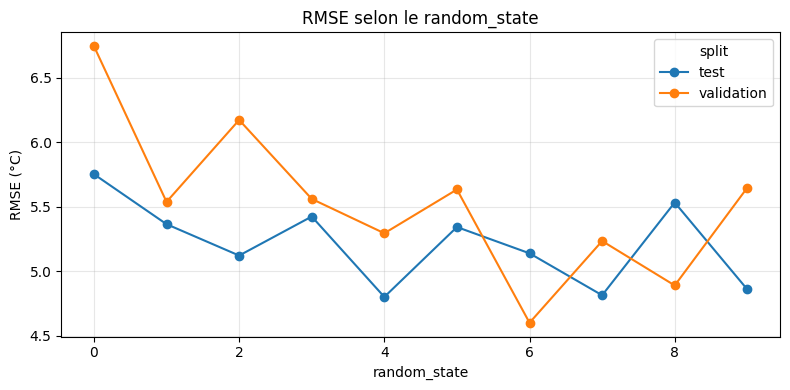


Exports :
 - outputs\meteofrance_data\tmrt_spatiotemporal_repeated_split_results.csv
 - outputs\meteofrance_data\tmrt_spatiotemporal_repeated_test_by_track.csv
 - outputs\meteofrance_data\tmrt_spatiotemporal_repeated_block_counts.csv
 - outputs\meteofrance_data\tmrt_spatiotemporal_repeated_summary.csv
 - outputs\meteofrance_data\tmrt_spatiotemporal_repeated_test_by_track_summary.csv


In [45]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 9 — Robustesse du split spatio-temporel (splits répétés)
# On garde best_grid_params fixe, et on fait varier seulement le tirage des blocs
# bloc = (track_id, day_utc)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split

try:
    params_for_repeats = best_grid_params.copy()
except NameError:
    params_for_repeats = {
        "l2_regularization": 0.1,
        "learning_rate": 0.05,
        "max_depth": 8,
        "max_iter": 500,
        "min_samples_leaf": 20,
    }

feat_cols_repeat = feat_cols_v2.copy()
seeds = list(range(10))   # change en range(5) si tu veux aller plus vite

def compute_metrics(y_true, pred):
    y_true = np.asarray(y_true, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return {
        "rmse": mean_squared_error(y_true, pred) ** 0.5,
        "mae": mean_absolute_error(y_true, pred),
        "r2": r2_score(y_true, pred),
        "bias": float(np.mean(y_true - pred)),
    }

def make_spatiotemporal_day_split(df, random_state):
    df = df.copy()

    df["st_day_block"] = (
        df["track_id"].astype(str)
        + "__" + df["day_utc"].dt.strftime("%Y-%m-%d")
    )

    day_blocks = (
        df[["track_id", "day_utc", "st_day_block"]]
        .drop_duplicates()
        .sort_values(["track_id", "day_utc"])
        .reset_index(drop=True)
    )

    split_map = {}

    for track_name, g in day_blocks.groupby("track_id", sort=False):
        blocks = g["st_day_block"].to_numpy()

        if len(blocks) < 5:
            raise ValueError(
                f"{track_name} n'a que {len(blocks)} jours, insuffisant pour un split train/val/test."
            )

        blocks_trainval, blocks_test = train_test_split(
            blocks,
            test_size=0.20,
            random_state=random_state,
            shuffle=True,
        )

        blocks_train, blocks_val = train_test_split(
            blocks_trainval,
            test_size=0.25,   # 0.25 de 80% = 20% total
            random_state=random_state,
            shuffle=True,
        )

        for b in blocks_train:
            split_map[b] = "train"
        for b in blocks_val:
            split_map[b] = "validation"
        for b in blocks_test:
            split_map[b] = "test"

    df["st_split"] = df["st_day_block"].map(split_map)

    if df["st_split"].isna().any():
        raise ValueError("Certains blocs jour/quartier n'ont pas reçu de split.")

    block_assign_df = day_blocks.copy()
    block_assign_df["st_split"] = block_assign_df["st_day_block"].map(split_map)

    return df, block_assign_df

repeat_results = []
repeat_test_track_results = []
repeat_block_results = []

for rs in seeds:
    split_df, block_assign_df = make_spatiotemporal_day_split(train, rs)

    train_mask = split_df["st_split"].eq("train")
    val_mask   = split_df["st_split"].eq("validation")
    test_mask  = split_df["st_split"].eq("test")

    X_train_rep = split_df.loc[train_mask, feat_cols_repeat]
    y_train_rep = split_df.loc[train_mask, TARGET].astype(float)

    X_val_rep = split_df.loc[val_mask, feat_cols_repeat]
    y_val_rep = split_df.loc[val_mask, TARGET].astype(float)

    X_test_rep = split_df.loc[test_mask, feat_cols_repeat]
    y_test_rep = split_df.loc[test_mask, TARGET].astype(float)

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("reg", HistGradientBoostingRegressor(random_state=42, **params_for_repeats))
    ])
    model.fit(X_train_rep, y_train_rep)

    for split_name, X_part, y_part in [
        ("validation", X_val_rep, y_val_rep),
        ("test", X_test_rep, y_test_rep),
    ]:
        pred = model.predict(X_part)
        metrics = compute_metrics(y_part, pred)

        repeat_results.append({
            "random_state": rs,
            "split": split_name,
            "rmse": metrics["rmse"],
            "mae": metrics["mae"],
            "r2": metrics["r2"],
            "bias": metrics["bias"],
            "n": len(y_part),
        })

        if split_name == "test":
            tmp = split_df.loc[test_mask, ["track_id", TARGET]].copy()
            tmp["tmrt_pred"] = pred

            for track_name, g in tmp.groupby("track_id"):
                track_metrics = compute_metrics(g[TARGET], g["tmrt_pred"])
                repeat_test_track_results.append({
                    "random_state": rs,
                    "track_id": track_name,
                    "rmse": track_metrics["rmse"],
                    "mae": track_metrics["mae"],
                    "r2": track_metrics["r2"],
                    "bias": track_metrics["bias"],
                    "n": len(g),
                })

    block_count_df = (
        block_assign_df.groupby(["st_split", "track_id"])
        .size()
        .reset_index(name="n_day_blocks")
    )
    block_count_df["random_state"] = rs
    repeat_block_results.append(block_count_df)

repeat_results_df = pd.DataFrame(repeat_results)
repeat_test_track_df = pd.DataFrame(repeat_test_track_results)
repeat_block_df = pd.concat(repeat_block_results, ignore_index=True)

repeat_summary_df = (
    repeat_results_df.groupby("split")[["rmse", "mae", "r2", "bias"]]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

repeat_test_track_summary_df = (
    repeat_test_track_df.groupby("track_id")[["rmse", "mae", "r2", "bias"]]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

print("=== Résultats par split et par seed ===")
display(repeat_results_df.round(4))

print("\n=== Synthèse globale ===")
display(repeat_summary_df)

print("\n=== Test par quartier et par seed ===")
display(repeat_test_track_df.round(4))

print("\n=== Synthèse test par quartier ===")
display(repeat_test_track_summary_df)

print("\n=== Répartition des blocs jour/quartier par seed ===")
display(
    repeat_block_df
    .sort_values(["random_state", "st_split", "track_id"])
    .reset_index(drop=True)
)

# Petit graphe RMSE validation/test selon le seed
plot_df = repeat_results_df.pivot(index="random_state", columns="split", values="rmse")
ax = plot_df.plot(marker="o", figsize=(8, 4))
ax.set_title("RMSE selon le random_state")
ax.set_ylabel("RMSE (°C)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Exports
repeat_results_out = MFDATA / "tmrt_spatiotemporal_repeated_split_results.csv"
repeat_test_track_out = MFDATA / "tmrt_spatiotemporal_repeated_test_by_track.csv"
repeat_block_out = MFDATA / "tmrt_spatiotemporal_repeated_block_counts.csv"

repeat_summary_out = MFDATA / "tmrt_spatiotemporal_repeated_summary.csv"
repeat_test_track_summary_out = MFDATA / "tmrt_spatiotemporal_repeated_test_by_track_summary.csv"

repeat_results_df.to_csv(repeat_results_out, index=False)
repeat_test_track_df.to_csv(repeat_test_track_out, index=False)
repeat_block_df.to_csv(repeat_block_out, index=False)

repeat_summary_export = repeat_summary_df.copy()
repeat_summary_export.columns = [f"{a}_{b}" for a, b in repeat_summary_export.columns]
repeat_summary_export = repeat_summary_export.reset_index()
repeat_summary_export.to_csv(repeat_summary_out, index=False)

repeat_test_track_summary_export = repeat_test_track_summary_df.copy()
repeat_test_track_summary_export.columns = [f"{a}_{b}" for a, b in repeat_test_track_summary_export.columns]
repeat_test_track_summary_export = repeat_test_track_summary_export.reset_index()
repeat_test_track_summary_export.to_csv(repeat_test_track_summary_out, index=False)

print("\nExports :")
print(" -", repeat_results_out)
print(" -", repeat_test_track_out)
print(" -", repeat_block_out)
print(" -", repeat_summary_out)
print(" -", repeat_test_track_summary_out)


In [46]:
%pip install catboost


   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   -- ------------------------------------- 5.8/100.2 MB 39.3 MB/s eta 0:00:03
   ------ --------------------------------- 15.5/100.2 MB 42.4 MB/s eta 0:00:03
   ---------- ----------------------------- 25.4/100.2 MB 46.0 MB/s eta 0:00:02
   -------------- ------------------------- 36.2/100.2 MB 46.9 MB/s eta 0:00:02
   ------------------- -------------------- 48.2/100.2 MB 48.8 MB/s eta 0:00:02
   ----------------------- ---------------- 59.8/100.2 MB 49.5 MB/s eta 0:00:01
   ---------------------------- ----------- 70.5/100.2 MB 50.0 MB/s eta 0:00:01
   -------------------------------- ------- 81.0/100.2 MB 49.7 MB/s eta 0:00:01
   ------------------------------------ --- 92.5/100.2 MB 50.5 MB/s eta 0:00:01
   --------------------------------------  100.1/100.2 MB 50.8 MB/s eta 0:00:01
   --------------------------------------- 100.2/100.2 MB 47.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
# ══════════════════════════════════════════════════════════════════════════════
# PISTE 10 — CatBoost sur le split spatio-temporel courant
# ══════════════════════════════════════════════════════════════════════════════

try:
    from catboost import CatBoostRegressor, Pool
except ImportError as e:
    raise ImportError("CatBoost n'est pas installé. Lance `%pip install catboost` puis relance.") from e

from sklearn.model_selection import ParameterGrid

def score_reg(y_true, pred):
    y_true = np.asarray(y_true, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return {
        "rmse": mean_squared_error(y_true, pred) ** 0.5,
        "mae": mean_absolute_error(y_true, pred),
        "r2": r2_score(y_true, pred),
        "bias": float(np.mean(y_true - pred)),
    }

# Features numériques déjà construites
feat_cols_num_cb = feat_cols_v2.copy()

# Catégorielles spatiales / contextuelles
cat_cols_cb = [c for c in ["track_id", "M_slot", "section_id", "segment_id"] if c in train.columns]

# Variante de départ : numériques + catégorielles
feat_cols_cb = feat_cols_num_cb + [c for c in cat_cols_cb if c not in feat_cols_num_cb]

X_train_cb = train.loc[train_mask, feat_cols_cb].copy()
y_train_cb = train.loc[train_mask, TARGET].astype(float).copy()

X_val_cb = train.loc[val_mask, feat_cols_cb].copy()
y_val_cb = train.loc[val_mask, TARGET].astype(float).copy()

X_test_cb = train.loc[test_mask, feat_cols_cb].copy()
y_test_cb = train.loc[test_mask, TARGET].astype(float).copy()

# CatBoost attend des catégorielles en str
for X_part in [X_train_cb, X_val_cb, X_test_cb]:
    for c in cat_cols_cb:
        X_part[c] = X_part[c].fillna("__NA__").astype(str)

pool_train_cb = Pool(X_train_cb, y_train_cb, cat_features=cat_cols_cb)
pool_val_cb   = Pool(X_val_cb, y_val_cb, cat_features=cat_cols_cb)
pool_test_cb  = Pool(X_test_cb, y_test_cb, cat_features=cat_cols_cb)

print("=== CatBoost setup ===")
print(f"Train      : {len(X_train_cb):,} lignes")
print(f"Validation : {len(X_val_cb):,} lignes")
print(f"Test       : {len(X_test_cb):,} lignes")
print(f"Num feats  : {len(feat_cols_num_cb)}")
print(f"Cat feats  : {cat_cols_cb}")
print(f"Total feats: {len(feat_cols_cb)}")


=== CatBoost setup ===
Train      : 156,180 lignes
Validation : 79,695 lignes
Test       : 105,406 lignes
Num feats  : 122
Cat feats  : ['track_id', 'M_slot', 'section_id', 'segment_id']
Total feats: 126


In [48]:
# ══════════════════════════════════════════════════════════════════════════════
# Grid search léger CatBoost sur validation spatio-temporelle
# ══════════════════════════════════════════════════════════════════════════════

param_grid_cb = {
    "depth": [6, 8],
    "learning_rate": [0.03, 0.05],
    "l2_leaf_reg": [3, 8],
}

cb_results = []
best_cb_model = None
best_cb_params = None
best_cb_val_rmse = float("inf")

for params in ParameterGrid(param_grid_cb):
    print("Test config:", params)

    model = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        iterations=2000,
        random_seed=42,
        allow_writing_files=False,
        thread_count=-1,
        **params,
    )

    model.fit(
        pool_train_cb,
        eval_set=pool_val_cb,
        use_best_model=True,
        early_stopping_rounds=100,
        verbose=False,
    )

    val_pred = model.predict(X_val_cb)
    val_metrics = score_reg(y_val_cb, val_pred)

    cb_results.append({
        **params,
        "best_iteration": int(model.get_best_iteration()),
        "rmse_val": val_metrics["rmse"],
        "mae_val": val_metrics["mae"],
        "r2_val": val_metrics["r2"],
        "bias_val": val_metrics["bias"],
    })

    if val_metrics["rmse"] < best_cb_val_rmse:
        best_cb_val_rmse = val_metrics["rmse"]
        best_cb_params = {
            **params,
            "best_iteration": int(model.get_best_iteration()),
        }
        best_cb_model = model

cb_results_df = pd.DataFrame(cb_results).sort_values("rmse_val").reset_index(drop=True)
display(cb_results_df.round(4))

print("\nMeilleure config CatBoost :", best_cb_params)
print(f"RMSE validation CatBoost : {best_cb_val_rmse:.4f} °C")


Test config: {'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Test config: {'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
Test config: {'depth': 6, 'l2_leaf_reg': 8, 'learning_rate': 0.03}
Test config: {'depth': 6, 'l2_leaf_reg': 8, 'learning_rate': 0.05}
Test config: {'depth': 8, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Test config: {'depth': 8, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
Test config: {'depth': 8, 'l2_leaf_reg': 8, 'learning_rate': 0.03}
Test config: {'depth': 8, 'l2_leaf_reg': 8, 'learning_rate': 0.05}


,depth,l2_leaf_reg,learning_rate,best_iteration,rmse_val,mae_val,r2_val,bias_val
0,6,8,0.05,541,4.7400,2.9301,0.6645,0.0084
1,6,3,0.03,1219,4.7678,2.9363,0.6605,0.0692
2,8,8,0.03,1980,4.7975,2.9090,0.6563,0.2607
3,8,3,0.03,972,4.8081,2.9216,0.6548,0.3700
4,6,8,0.03,858,4.8093,2.9876,0.6546,0.0979
5,8,8,0.05,661,4.9030,2.9932,0.6410,0.2217
6,6,3,0.05,629,4.9104,3.0965,0.6399,-0.0903
7,8,3,0.05,703,4.9250,3.0082,0.6378,0.3612



Meilleure config CatBoost : {'depth': 6, 'l2_leaf_reg': 8, 'learning_rate': 0.05, 'best_iteration': 541}
RMSE validation CatBoost : 4.7400 °C


In [49]:
# ══════════════════════════════════════════════════════════════════════════════
# Évaluation finale CatBoost sur validation + test
# ══════════════════════════════════════════════════════════════════════════════

val_pred_cb = best_cb_model.predict(X_val_cb)
test_pred_cb = best_cb_model.predict(X_test_cb)

val_metrics_cb = {"split": "validation", **score_reg(y_val_cb, val_pred_cb), "n": len(y_val_cb)}
test_metrics_cb = {"split": "test", **score_reg(y_test_cb, test_pred_cb), "n": len(y_test_cb)}

cb_eval_df = pd.DataFrame([val_metrics_cb, test_metrics_cb])
display(cb_eval_df.round(4))

print(f"Validation RMSE CatBoost : {val_metrics_cb['rmse']:.4f} °C")
print(f"Test final RMSE CatBoost : {test_metrics_cb['rmse']:.4f} °C")

# Détail test par quartier
test_pred_cb_df = train.loc[test_mask, ["track_id", TARGET]].copy()
test_pred_cb_df["tmrt_pred"] = test_pred_cb

cb_test_by_track_df = pd.DataFrame([
    {
        "track_id": track_name,
        **score_reg(g[TARGET], g["tmrt_pred"]),
        "n": len(g),
    }
    for track_name, g in test_pred_cb_df.groupby("track_id")
]).sort_values("rmse").reset_index(drop=True)

print("\nDétail test CatBoost par quartier :")
display(cb_test_by_track_df.round(4))

# Feature importance
cb_fi_df = (
    pd.DataFrame({
        "feature": feat_cols_cb,
        "importance": best_cb_model.get_feature_importance(pool_train_cb),
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 25 features CatBoost :")
display(cb_fi_df.head(25).round(4))

# Exports
export_cols_cb = [
    c for c in [
        "uid", "timestamp", "timestamp_utc", TARGET,
        "track_id", "M_slot", "day_utc", "section_id",
        "segment_id", "lon_ontrack", "lat_ontrack",
        "st_day_block", "st_split"
    ]
    if c in train.columns
]

val_export_cb = train.loc[val_mask, export_cols_cb].copy()
val_export_cb["tmrt_pred"] = val_pred_cb
val_export_cb["err"] = val_pred_cb - y_val_cb.to_numpy()

test_export_cb = train.loc[test_mask, export_cols_cb].copy()
test_export_cb["tmrt_pred"] = test_pred_cb
test_export_cb["err"] = test_pred_cb - y_test_cb.to_numpy()

cb_results_path = MFDATA / "tmrt_catboost_grid_results.csv"
cb_eval_path = MFDATA / "tmrt_catboost_eval.csv"
cb_track_path = MFDATA / "tmrt_catboost_test_by_track.csv"
cb_val_pred_path = MFDATA / "tmrt_catboost_pred_validation.csv"
cb_test_pred_path = MFDATA / "tmrt_catboost_pred_test.csv"
cb_fi_path = MFDATA / "tmrt_catboost_feature_importance.csv"

cb_results_df.to_csv(cb_results_path, index=False)
cb_eval_df.to_csv(cb_eval_path, index=False)
cb_test_by_track_df.to_csv(cb_track_path, index=False)
val_export_cb.to_csv(cb_val_pred_path, index=False)
test_export_cb.to_csv(cb_test_pred_path, index=False)
cb_fi_df.to_csv(cb_fi_path, index=False)

print("\nExports :")
print(" -", cb_results_path)
print(" -", cb_eval_path)
print(" -", cb_track_path)
print(" -", cb_val_pred_path)
print(" -", cb_test_pred_path)
print(" -", cb_fi_path)


,split,rmse,mae,r2,bias,n
0,validation,4.7400,2.9301,0.6645,0.0084,79695
1,test,4.6629,2.8218,0.5941,0.2308,105406


Validation RMSE CatBoost : 4.7400 °C
Test final RMSE CatBoost : 4.6629 °C

Détail test CatBoost par quartier :


,track_id,rmse,mae,r2,bias,n
0,ecusson,4.4070,2.5640,0.4971,0.0244,36100
1,antigone,4.4788,2.8636,0.6170,0.2005,34121
2,boulevards,5.0749,3.0457,0.5590,0.4719,35185



Top 25 features CatBoost :


,feature,importance
0,T_x_elev,11.7991
1,GLO_x_elev,7.9240
2,apparent_T,5.2619
3,A35,4.8066
4,GLO,4.0890
5,A52,3.9267
6,A53,3.5380
7,doy_cos,3.3393
8,T,2.8777
9,solar_azimuth,2.8151



Exports :
 - outputs\meteofrance_data\tmrt_catboost_grid_results.csv
 - outputs\meteofrance_data\tmrt_catboost_eval.csv
 - outputs\meteofrance_data\tmrt_catboost_test_by_track.csv
 - outputs\meteofrance_data\tmrt_catboost_pred_validation.csv
 - outputs\meteofrance_data\tmrt_catboost_pred_test.csv
 - outputs\meteofrance_data\tmrt_catboost_feature_importance.csv
